# Predictive Modeling for Football Match Outcomes (Premier League)

This project aims to predict football match outcomes, specifically the Over/Under 2.5 goals market in the English Premier League. The project involves web scraping, feature engineering, statistical modeling (Poisson regression), and machine learning approaches. Visual analysis is performed using Power BI.


This section ensures that all necessary Python libraries are installed. 
We use `wget` for downloading files directly from the web and other libraries for data manipulation, modeling, and visualization.


## 1. Installing Required Libraries

In [ ]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=9b634d00424f85da1f38c66fb4b9f96d5a4310f413d42b7e4c9a2516f07cf131
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


Here we import all required libraries for data processing, web scraping, visualization, and machine learning.
- `pandas`, `numpy`: data manipulation
- `matplotlib`, `seaborn`: plotting
- `sklearn`: machine learning models and evaluation
- Other libraries for automation and environment configuration


## 2. Importing Libraries

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import wget

from scipy.stats import poisson
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import time
from datetime import datetime
from requests import get
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This section handles Google Drive authentication so we can access and save files in the cloud using Google Colab. 
The dataset used in this project is stored in the user’s Google Drive.


## 3. Authentication and Google Drive Setup

In [ ]:
# from google.colab import auth
# auth.authenticate_user()

# import gspread
# from google.auth import default
# creds, _ = default()

# gc = gspread.authorize(creds)

##1.1 Variáveis

In [ ]:
## Variáveis:

ano_corrente = 2024
match_round = 'Matchweek 26'
data_analise_inicio = '2024-01-13'
data_analise_final = '2024-02-03'
filter_date = '2024-02-21'
data_teste = '2024-02-17'
data_corte_teste = '2024-02-17'

We collect match data for the English Premier League through web scraping.
This includes:
- Match results
- Goals scored
- Home/away statistics

The data spans multiple seasons and serves as the raw input for feature engineering and modeling.


## 4. Data Collection (Web Scraping)

In [ ]:
domain = 'https://www.football-data.co.uk'
url = 'https://www.football-data.co.uk/englandm.php'
format = '.csv'

In [ ]:
text = BeautifulSoup(requests.get(url).text, 'html.parser')
link = text.find_all('a', href = True, string="Premier League" )
links = [l.get("href") for l in link]
response = wget.download(domain + '/' +  links[0])

In [ ]:
df = pd.read_csv('E0.csv')
df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,19/05/2024,16:00,Crystal Palace,Aston Villa,5,0,H,2,0,...,2.78,-0.75,1.73,2.08,1.78,2.16,1.93,2.21,1.81,2.05
376,E0,19/05/2024,16:00,Liverpool,Wolves,2,0,H,2,0,...,5.17,-2.75,2.07,1.86,2.04,1.85,2.10,1.89,2.04,1.82
377,E0,19/05/2024,16:00,Luton,Fulham,2,4,A,1,2,...,2.69,0.25,2.00,1.93,1.99,1.93,2.02,1.94,1.96,1.91
378,E0,19/05/2024,16:00,Man City,West Ham,3,1,H,2,1,...,4.82,-3.00,2.03,1.90,1.99,1.90,2.05,1.99,1.96,1.91


In [ ]:
anos = list(range(2023, 2014, -1))
lista_colunas = ["Div","Date","Time","HomeTeam","AwayTeam","FTHG","HG","FTAG","AG","FTR","HTHG","HTAG","HTR","Referee","HS","AS","HST","AST","HC","AC","HF","AF","HFKC","AFKC","HO","AO","HY","AY","HR","AR","B365<2.5","B365>2.5"]
all_matches = []

for i in range(len(anos)):
  team_data = pd.read_csv(f'/content/drive/MyDrive/Apostas/Premier_league/{anos[i]}.csv', sep = ',')
  team_data = team_data[team_data.columns.intersection(lista_colunas)]
  team_data["Season"] = anos[i]
  team_data['Date'].astype(str)
  team_data.dropna(subset = ['Div'], inplace=True)
  if team_data['Date'][0][6:8] != '20':
    team_data['dia'] = team_data['Date'].astype(str).str[:2]
    team_data['mes'] = team_data['Date'].astype(str).str[3:5]
    team_data['ano'] = team_data['Date'].astype(str).str[6:8]
    team_data['date_cor'] = team_data['dia'] + '/' +  team_data['mes'] + '/' + '20' + team_data['ano']
    # df["date_cor"] = pd.to_datetime(df["Date"])
    del team_data['Date']
    team_data.rename(columns={"date_cor": "Date"}, inplace=True)
  all_matches.append(team_data)

team_data = df[df.columns.intersection(lista_colunas)]
team_data["Season"] = ano_corrente
team_data['Date'].astype(str)
team_data.dropna(subset = ['Div'], inplace=True)
all_matches.append(team_data)

<ipython-input-9-418c2ce252f6>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_data["Season"] = ano_corrente
<ipython-input-9-418c2ce252f6>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_data.dropna(subset = ['Div'], inplace=True)


In [ ]:
match_df = pd.concat(all_matches)
match_df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,HY,AY,HR,AR,B365>2.5,B365<2.5,Season,dia,mes,ano
0,E0,05/08/2022,20:00,Crystal Palace,Arsenal,0.0,2.0,A,0.0,1.0,...,1.0,2.0,0.0,0.0,2.10,1.72,2023,NaN,NaN,NaN
1,E0,06/08/2022,12:30,Fulham,Liverpool,2.0,2.0,D,1.0,0.0,...,2.0,0.0,0.0,0.0,1.50,2.62,2023,NaN,NaN,NaN
2,E0,06/08/2022,15:00,Bournemouth,Aston Villa,2.0,0.0,H,1.0,0.0,...,3.0,3.0,0.0,0.0,2.00,1.80,2023,NaN,NaN,NaN
3,E0,06/08/2022,15:00,Leeds,Wolves,2.0,1.0,H,1.0,1.0,...,2.0,0.0,0.0,0.0,2.05,1.85,2023,NaN,NaN,NaN
4,E0,06/08/2022,15:00,Newcastle,Nott'm Forest,2.0,0.0,H,0.0,0.0,...,0.0,3.0,0.0,0.0,2.05,1.85,2023,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,19/05/2024,16:00,Crystal Palace,Aston Villa,5.0,0.0,H,2.0,0.0,...,1.0,4.0,0.0,0.0,1.40,3.00,2024,NaN,NaN,NaN
376,E0,19/05/2024,16:00,Liverpool,Wolves,2.0,0.0,H,2.0,0.0,...,1.0,1.0,0.0,1.0,1.22,4.33,2024,NaN,NaN,NaN
377,E0,19/05/2024,16:00,Luton,Fulham,2.0,4.0,A,1.0,2.0,...,5.0,4.0,0.0,0.0,1.44,2.75,2024,NaN,NaN,NaN
378,E0,19/05/2024,16:00,Man City,West Ham,3.0,1.0,H,2.0,1.0,...,0.0,1.0,0.0,0.0,1.20,4.50,2024,NaN,NaN,NaN


In [ ]:
match_df["Date"] = pd.to_datetime(match_df["Date"], format="%d/%m/%Y")

In [ ]:
match_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3800 entries, 0 to 379
Data columns (total 30 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Div       3800 non-null   object        
 1   Date      3800 non-null   datetime64[ns]
 2   Time      1900 non-null   object        
 3   HomeTeam  3800 non-null   object        
 4   AwayTeam  3800 non-null   object        
 5   FTHG      3800 non-null   float64       
 6   FTAG      3800 non-null   float64       
 7   FTR       3800 non-null   object        
 8   HTHG      3800 non-null   float64       
 9   HTAG      3800 non-null   float64       
 10  HTR       3800 non-null   object        
 11  Referee   3800 non-null   object        
 12  HS        3800 non-null   float64       
 13  AS        3800 non-null   float64       
 14  HST       3800 non-null   float64       
 15  AST       3800 non-null   float64       
 16  HF        3800 non-null   float64       
 17  AF        3800 non-n

In [ ]:
df_final = match_df.sort_values(by = 'Date', ascending = False).reset_index(drop = True)
df_final = df_final.reset_index(drop = True)
df_final

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,HY,AY,HR,AR,B365>2.5,B365<2.5,Season,dia,mes,ano
0,E0,2024-05-19,16:00,Sheffield United,Tottenham,0.0,3.0,A,0.0,1.0,...,2.0,0.0,0.0,0.0,1.22,4.33,2024,NaN,NaN,NaN
1,E0,2024-05-19,16:00,Man City,West Ham,3.0,1.0,H,2.0,1.0,...,0.0,1.0,0.0,0.0,1.20,4.50,2024,NaN,NaN,NaN
2,E0,2024-05-19,16:00,Liverpool,Wolves,2.0,0.0,H,2.0,0.0,...,1.0,1.0,0.0,1.0,1.22,4.33,2024,NaN,NaN,NaN
3,E0,2024-05-19,16:00,Crystal Palace,Aston Villa,5.0,0.0,H,2.0,0.0,...,1.0,4.0,0.0,0.0,1.40,3.00,2024,NaN,NaN,NaN
4,E0,2024-05-19,16:00,Chelsea,Bournemouth,2.0,1.0,H,1.0,0.0,...,2.0,3.0,0.0,0.0,1.29,3.75,2024,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,E0,2014-08-16,NaN,West Ham,Tottenham,0.0,1.0,A,0.0,0.0,...,1.0,0.0,1.0,1.0,NaN,NaN,2015,16,08,14
3796,E0,2014-08-16,NaN,Man United,Swansea,1.0,2.0,A,0.0,1.0,...,2.0,4.0,0.0,0.0,NaN,NaN,2015,16,08,14
3797,E0,2014-08-16,NaN,Leicester,Everton,2.0,2.0,D,1.0,2.0,...,1.0,1.0,0.0,0.0,NaN,NaN,2015,16,08,14
3798,E0,2014-08-16,NaN,Arsenal,Crystal Palace,2.0,1.0,H,1.0,1.0,...,2.0,2.0,0.0,1.0,NaN,NaN,2015,16,08,14


This is a key stage where we transform raw match data into structured features:
- Calculation of rolling averages and cumulative stats (goals, points, etc.)
- Encoding of match context (e.g., home/away, round number)
- Creation of target variables for prediction (e.g., over/under 2.5 goals)
These steps are essential to extract meaningful patterns that models can learn from.


## 5. Data Preprocessing and Feature Engineering

In [ ]:
home_col = ["Date","Time","HomeTeam","AwayTeam","FTHG","FTAG","FTR","HTHG","HTR","Referee","HS","HST","HF","HC","HY","HR","AS","AST","AF","AC","AY","AR","B365<2.5","B365>2.5","Season"]
away_col = ["Date","Time","AwayTeam","HomeTeam","FTHG","FTAG","FTR","HTAG","HTR","Referee","HS","HST","HF","HC","HY","HR","AS","AST","AF","AC","AY","AR","B365<2.5","B365>2.5","Season"]

home = df_final[df_final.columns.intersection(home_col)]
away = df_final[df_final.columns.intersection(away_col)]

home.rename(columns={"AwayTeam": "Against", "HomeTeam": "Team", "FTHG": 'FTG', "FTAG": 'FTGA',"HTHG":'HTG',
                     "HS": 'SH',"HST": 'STH',"HF": "FH","HC": 'CH',"HY": 'YH',"HR": "RH", "B365H": 'B365H',
                     "AS": 'SA',"AST": 'STA',"AF": "FA","AC": 'CA',"AY": 'YA',"AR": "RA", "B365A": 'B365A'}, inplace=True)
away.rename(columns={"HomeTeam": "Against", "AwayTeam": "Team", "FTAG": 'FTG', "FTHG": 'FTGA',"HTAG":'HTG',
                     "AS": 'SH',"AST": 'STH',"AF": "FH","AC": 'CH',"AY": 'YH',"AR": "RH", "B365A": 'B365H',
                     "HS": 'SA',"HST": 'STA',"HF": "FA","HC": 'CA',"HY": 'YA',"HR": "RA", "B365A": 'B365A'}, inplace=True)

home['venue'] = "Home"
away['venue'] = "Away"

<ipython-input-14-221594843a3d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home.rename(columns={"AwayTeam": "Against", "HomeTeam": "Team", "FTHG": 'FTG', "FTAG": 'FTGA',"HTHG":'HTG',
<ipython-input-14-221594843a3d>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  away.rename(columns={"HomeTeam": "Against", "AwayTeam": "Team", "FTAG": 'FTG', "FTHG": 'FTGA',"HTAG":'HTG',
<ipython-input-14-221594843a3d>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

In [ ]:
home

,Date,Time,Team,Against,FTG,FTGA,FTR,HTG,HTR,Referee,...,CH,CA,YH,YA,RH,RA,B365>2.5,B365<2.5,Season,venue
0,2024-05-19,16:00,Sheffield United,Tottenham,0.0,3.0,A,0.0,A,A Madley,...,2.0,6.0,2.0,0.0,0.0,0.0,1.22,4.33,2024,Home
1,2024-05-19,16:00,Man City,West Ham,3.0,1.0,H,2.0,H,J Brooks,...,11.0,2.0,0.0,1.0,0.0,0.0,1.20,4.50,2024,Home
2,2024-05-19,16:00,Liverpool,Wolves,2.0,0.0,H,2.0,H,C Kavanagh,...,10.0,2.0,1.0,1.0,0.0,1.0,1.22,4.33,2024,Home
3,2024-05-19,16:00,Crystal Palace,Aston Villa,5.0,0.0,H,2.0,H,D Bond,...,2.0,4.0,1.0,4.0,0.0,0.0,1.40,3.00,2024,Home
4,2024-05-19,16:00,Chelsea,Bournemouth,2.0,1.0,H,1.0,H,A Taylor,...,6.0,5.0,2.0,3.0,0.0,0.0,1.29,3.75,2024,Home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,2014-08-16,NaN,West Ham,Tottenham,0.0,1.0,A,0.0,D,C Foy,...,8.0,5.0,1.0,0.0,1.0,1.0,NaN,NaN,2015,Home
3796,2014-08-16,NaN,Man United,Swansea,1.0,2.0,A,0.0,A,M Dean,...,4.0,0.0,2.0,4.0,0.0,0.0,NaN,NaN,2015,Home
3797,2014-08-16,NaN,Leicester,Everton,2.0,2.0,D,1.0,A,M Jones,...,3.0,6.0,1.0,1.0,0.0,0.0,NaN,NaN,2015,Home
3798,2014-08-16,NaN,Arsenal,Crystal Palace,2.0,1.0,H,1.0,D,J Moss,...,9.0,3.0,2.0,2.0,0.0,1.0,NaN,NaN,2015,Home


In [ ]:
away

,Date,Time,Against,Team,FTGA,FTG,FTR,HTG,HTR,Referee,...,CA,CH,YA,YH,RA,RH,B365>2.5,B365<2.5,Season,venue
0,2024-05-19,16:00,Sheffield United,Tottenham,0.0,3.0,A,1.0,A,A Madley,...,2.0,6.0,2.0,0.0,0.0,0.0,1.22,4.33,2024,Away
1,2024-05-19,16:00,Man City,West Ham,3.0,1.0,H,1.0,H,J Brooks,...,11.0,2.0,0.0,1.0,0.0,0.0,1.20,4.50,2024,Away
2,2024-05-19,16:00,Liverpool,Wolves,2.0,0.0,H,0.0,H,C Kavanagh,...,10.0,2.0,1.0,1.0,0.0,1.0,1.22,4.33,2024,Away
3,2024-05-19,16:00,Crystal Palace,Aston Villa,5.0,0.0,H,0.0,H,D Bond,...,2.0,4.0,1.0,4.0,0.0,0.0,1.40,3.00,2024,Away
4,2024-05-19,16:00,Chelsea,Bournemouth,2.0,1.0,H,0.0,H,A Taylor,...,6.0,5.0,2.0,3.0,0.0,0.0,1.29,3.75,2024,Away
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,2014-08-16,NaN,West Ham,Tottenham,0.0,1.0,A,0.0,D,C Foy,...,8.0,5.0,1.0,0.0,1.0,1.0,NaN,NaN,2015,Away
3796,2014-08-16,NaN,Man United,Swansea,1.0,2.0,A,1.0,A,M Dean,...,4.0,0.0,2.0,4.0,0.0,0.0,NaN,NaN,2015,Away
3797,2014-08-16,NaN,Leicester,Everton,2.0,2.0,D,2.0,A,M Jones,...,3.0,6.0,1.0,1.0,0.0,0.0,NaN,NaN,2015,Away
3798,2014-08-16,NaN,Arsenal,Crystal Palace,2.0,1.0,H,1.0,D,J Moss,...,9.0,3.0,2.0,2.0,0.0,1.0,NaN,NaN,2015,Away


In [ ]:
for i in range(len(home['FTR'])):
  if home['FTR'][i] == 'H':
    home['FTR'][i] = 1
  elif home['FTR'][i] == 'D':
    home['FTR'][i] = 2
  else:
    home['FTR'][i] = 0

for i in range(len(home['HTR'])):
  if home['HTR'][i] == 'H':
    home['HTR'][i] = 1
  elif home['HTR'][i] == 'D':
    home['HTR'][i] = 2
  else:
    home['HTR'][i] = 0

A saída de streaming foi truncada nas últimas 5000 linhas.
<ipython-input-17-d3e32182f7ec>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home['HTR'][i] = 1
<ipython-input-17-d3e32182f7ec>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home['HTR'][i] = 0
<ipython-input-17-d3e32182f7ec>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home['HTR'][i] = 1
<ipython-input-17-d3e32182f7ec>:15: SettingWithCopyWarning: 
A value is tryin

In [ ]:
for i in range(len(away['FTR'])):
  if away['FTR'][i] == 'A':
    away['FTR'][i] = 1
  elif away['FTR'][i] == 'D':
    away['FTR'][i] = 2
  else:
    away['FTR'][i] = 0

for i in range(len(away['HTR'])):
  if away['HTR'][i] == 'H':
    away['HTR'][i] = 1
  elif away['HTR'][i] == 'D':
    away['HTR'][i] = 2
  else:
    away['HTR'][i] = 0

A saída de streaming foi truncada nas últimas 5000 linhas.
<ipython-input-18-68e7ce3cd7c2>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  away['HTR'][i] = 1
<ipython-input-18-68e7ce3cd7c2>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  away['HTR'][i] = 0
<ipython-input-18-68e7ce3cd7c2>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  away['HTR'][i] = 1
<ipython-input-18-68e7ce3cd7c2>:15: SettingWithCopyWarning: 
A value is tryin

In [ ]:
df_premier = pd.concat([home, away], ignore_index=True)
df_premier = df_premier.sort_values(by = 'Date', ascending = False).reset_index(drop = True)
df_premier

,Date,Time,Team,Against,FTG,FTGA,FTR,HTG,HTR,Referee,...,CH,CA,YH,YA,RH,RA,B365>2.5,B365<2.5,Season,venue
0,2024-05-19,16:00,Sheffield United,Tottenham,0.0,3.0,0,0.0,0,A Madley,...,2.0,6.0,2.0,0.0,0.0,0.0,1.22,4.33,2024,Home
1,2024-05-19,16:00,Man City,West Ham,3.0,1.0,1,2.0,1,J Brooks,...,11.0,2.0,0.0,1.0,0.0,0.0,1.20,4.50,2024,Home
2,2024-05-19,16:00,Fulham,Luton,4.0,2.0,1,2.0,0,M Donohue,...,4.0,4.0,4.0,5.0,0.0,0.0,1.44,2.75,2024,Away
3,2024-05-19,16:00,Everton,Arsenal,1.0,2.0,0,1.0,2,M Oliver,...,1.0,8.0,3.0,4.0,0.0,0.0,1.36,3.20,2024,Away
4,2024-05-19,16:00,Newcastle,Brentford,4.0,2.0,1,3.0,0,S Hooper,...,0.0,3.0,4.0,4.0,0.0,0.0,1.36,3.20,2024,Away
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7595,2014-08-16,NaN,West Brom,Sunderland,2.0,2.0,2,1.0,2,N Swarbrick,...,6.0,3.0,3.0,1.0,0.0,0.0,NaN,NaN,2015,Home
7596,2014-08-16,NaN,Stoke,Aston Villa,0.0,1.0,0,0.0,2,A Taylor,...,2.0,8.0,0.0,3.0,0.0,0.0,NaN,NaN,2015,Home
7597,2014-08-16,NaN,West Ham,Tottenham,0.0,1.0,0,0.0,2,C Foy,...,8.0,5.0,1.0,0.0,1.0,1.0,NaN,NaN,2015,Home
7598,2014-08-16,NaN,Man United,Swansea,1.0,2.0,0,0.0,0,M Dean,...,4.0,0.0,2.0,4.0,0.0,0.0,NaN,NaN,2015,Home


In [ ]:
points = []
for i in range(len(df_premier['FTR'])):
  if df_premier['FTR'][i] == 1:
    points.append(3)
  elif df_premier['FTR'][i] == 0:
    points.append(1)
  else:
    points.append(0)

df_premier['points'] = points

In [ ]:
df_premier

,Date,Time,Team,Against,FTG,FTGA,FTR,HTG,HTR,Referee,...,CA,YH,YA,RH,RA,B365>2.5,B365<2.5,Season,venue,points
0,2024-05-19,16:00,Sheffield United,Tottenham,0.0,3.0,0,0.0,0,A Madley,...,6.0,2.0,0.0,0.0,0.0,1.22,4.33,2024,Home,1
1,2024-05-19,16:00,Man City,West Ham,3.0,1.0,1,2.0,1,J Brooks,...,2.0,0.0,1.0,0.0,0.0,1.20,4.50,2024,Home,3
2,2024-05-19,16:00,Fulham,Luton,4.0,2.0,1,2.0,0,M Donohue,...,4.0,4.0,5.0,0.0,0.0,1.44,2.75,2024,Away,3
3,2024-05-19,16:00,Everton,Arsenal,1.0,2.0,0,1.0,2,M Oliver,...,8.0,3.0,4.0,0.0,0.0,1.36,3.20,2024,Away,1
4,2024-05-19,16:00,Newcastle,Brentford,4.0,2.0,1,3.0,0,S Hooper,...,3.0,4.0,4.0,0.0,0.0,1.36,3.20,2024,Away,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7595,2014-08-16,NaN,West Brom,Sunderland,2.0,2.0,2,1.0,2,N Swarbrick,...,3.0,3.0,1.0,0.0,0.0,NaN,NaN,2015,Home,0
7596,2014-08-16,NaN,Stoke,Aston Villa,0.0,1.0,0,0.0,2,A Taylor,...,8.0,0.0,3.0,0.0,0.0,NaN,NaN,2015,Home,1
7597,2014-08-16,NaN,West Ham,Tottenham,0.0,1.0,0,0.0,2,C Foy,...,5.0,1.0,0.0,1.0,1.0,NaN,NaN,2015,Home,1
7598,2014-08-16,NaN,Man United,Swansea,1.0,2.0,0,0.0,0,M Dean,...,0.0,2.0,4.0,0.0,0.0,NaN,NaN,2015,Home,1


In [ ]:
df_premier.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      7600 non-null   datetime64[ns]
 1   Time      3800 non-null   object        
 2   Team      7600 non-null   object        
 3   Against   7600 non-null   object        
 4   FTG       7600 non-null   float64       
 5   FTGA      7600 non-null   float64       
 6   FTR       7600 non-null   object        
 7   HTG       7600 non-null   float64       
 8   HTR       7600 non-null   object        
 9   Referee   7600 non-null   object        
 10  SH        7600 non-null   float64       
 11  SA        7600 non-null   float64       
 12  STH       7600 non-null   float64       
 13  STA       7600 non-null   float64       
 14  FH        7600 non-null   float64       
 15  FA        7600 non-null   float64       
 16  CH        7600 non-null   float64       
 17  CA        7600

In [ ]:
matches = df_premier
matches.columns = [c.lower() for c in matches.columns]
matches.rename(columns={"Nome do Dia": "Against"}, inplace=True)
matches

,date,time,team,against,ftg,ftga,ftr,htg,htr,referee,...,ca,yh,ya,rh,ra,b365>2.5,b365<2.5,season,venue,points
0,2024-05-19,16:00,Sheffield United,Tottenham,0.0,3.0,0,0.0,0,A Madley,...,6.0,2.0,0.0,0.0,0.0,1.22,4.33,2024,Home,1
1,2024-05-19,16:00,Man City,West Ham,3.0,1.0,1,2.0,1,J Brooks,...,2.0,0.0,1.0,0.0,0.0,1.20,4.50,2024,Home,3
2,2024-05-19,16:00,Fulham,Luton,4.0,2.0,1,2.0,0,M Donohue,...,4.0,4.0,5.0,0.0,0.0,1.44,2.75,2024,Away,3
3,2024-05-19,16:00,Everton,Arsenal,1.0,2.0,0,1.0,2,M Oliver,...,8.0,3.0,4.0,0.0,0.0,1.36,3.20,2024,Away,1
4,2024-05-19,16:00,Newcastle,Brentford,4.0,2.0,1,3.0,0,S Hooper,...,3.0,4.0,4.0,0.0,0.0,1.36,3.20,2024,Away,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7595,2014-08-16,NaN,West Brom,Sunderland,2.0,2.0,2,1.0,2,N Swarbrick,...,3.0,3.0,1.0,0.0,0.0,NaN,NaN,2015,Home,0
7596,2014-08-16,NaN,Stoke,Aston Villa,0.0,1.0,0,0.0,2,A Taylor,...,8.0,0.0,3.0,0.0,0.0,NaN,NaN,2015,Home,1
7597,2014-08-16,NaN,West Ham,Tottenham,0.0,1.0,0,0.0,2,C Foy,...,5.0,1.0,0.0,1.0,1.0,NaN,NaN,2015,Home,1
7598,2014-08-16,NaN,Man United,Swansea,1.0,2.0,0,0.0,0,M Dean,...,0.0,2.0,4.0,0.0,0.0,NaN,NaN,2015,Home,1


In [ ]:
matches = matches.sort_values(['date'], ascending = [True]).reset_index(drop = True)
matches[-50:]

,date,time,team,against,ftg,ftga,ftr,htg,htr,referee,...,ca,yh,ya,rh,ra,b365>2.5,b365<2.5,season,venue,points
7550,2024-05-05,14:00,Aston Villa,Brighton,0.0,1.0,0,0.0,2,R Jones,...,7.0,1.0,2.0,0.0,0.0,1.50,2.63,2024,Away,1
7551,2024-05-05,14:00,Chelsea,West Ham,5.0,0.0,1,3.0,1,A Madley,...,6.0,1.0,3.0,0.0,0.0,1.40,3.00,2024,Home,3
7552,2024-05-06,20:00,Man United,Crystal Palace,0.0,4.0,0,0.0,1,J Gillett,...,6.0,1.0,1.0,0.0,0.0,1.53,2.50,2024,Away,1
7553,2024-05-06,20:00,Crystal Palace,Man United,4.0,0.0,1,2.0,1,J Gillett,...,3.0,1.0,1.0,0.0,0.0,1.53,2.50,2024,Home,3
7554,2024-05-11,15:00,West Ham,Luton,3.0,1.0,1,0.0,0,M Oliver,...,6.0,1.0,3.0,0.0,0.0,1.44,2.75,2024,Home,3
7555,2024-05-11,15:00,Wolves,Crystal Palace,1.0,3.0,0,0.0,0,T Bramall,...,3.0,3.0,2.0,0.0,1.0,1.80,2.00,2024,Home,1
7556,2024-05-11,15:00,Everton,Sheffield United,1.0,0.0,1,1.0,1,S Attwell,...,6.0,1.0,2.0,0.0,0.0,1.53,2.50,2024,Home,3
7557,2024-05-11,15:00,Bournemouth,Brentford,1.0,2.0,0,0.0,2,M Donohue,...,8.0,2.0,2.0,0.0,0.0,1.44,2.75,2024,Home,1
7558,2024-05-11,12:30,Fulham,Man City,0.0,4.0,0,0.0,0,A Taylor,...,7.0,1.0,0.0,1.0,0.0,1.36,3.20,2024,Home,1
7559,2024-05-11,15:00,Newcastle,Brighton,1.0,1.0,2,1.0,2,D England,...,4.0,3.0,4.0,0.0,0.0,1.33,3.40,2024,Home,0


In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      7600 non-null   datetime64[ns]
 1   time      3800 non-null   object        
 2   team      7600 non-null   object        
 3   against   7600 non-null   object        
 4   ftg       7600 non-null   float64       
 5   ftga      7600 non-null   float64       
 6   ftr       7600 non-null   object        
 7   htg       7600 non-null   float64       
 8   htr       7600 non-null   object        
 9   referee   7600 non-null   object        
 10  sh        7600 non-null   float64       
 11  sa        7600 non-null   float64       
 12  sth       7600 non-null   float64       
 13  sta       7600 non-null   float64       
 14  fh        7600 non-null   float64       
 15  fa        7600 non-null   float64       
 16  ch        7600 non-null   float64       
 17  ca        7600

In [ ]:
matches = matches[['date','time','team','against','ftg','ftga','ftr','htg','htr','sh','sa','sth','sta','fh','fa','ch','ca','yh','ya','rh','ra','points' , 'season','venue', 'b365>2.5', 'b365<2.5']]
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      7600 non-null   datetime64[ns]
 1   time      3800 non-null   object        
 2   team      7600 non-null   object        
 3   against   7600 non-null   object        
 4   ftg       7600 non-null   float64       
 5   ftga      7600 non-null   float64       
 6   ftr       7600 non-null   object        
 7   htg       7600 non-null   float64       
 8   htr       7600 non-null   object        
 9   sh        7600 non-null   float64       
 10  sa        7600 non-null   float64       
 11  sth       7600 non-null   float64       
 12  sta       7600 non-null   float64       
 13  fh        7600 non-null   float64       
 14  fa        7600 non-null   float64       
 15  ch        7600 non-null   float64       
 16  ca        7600 non-null   float64       
 17  yh        7600

In [ ]:
matches["ftr"] = matches['ftr'].astype(str).astype(int)
matches["htr"] = matches['htr'].astype(str).astype(int)
matches["venue_code"] = matches["venue"].astype("category").cat.codes
matches["opp_code"] = matches["against"].astype("category").cat.codes
matches["team_code"] = matches["team"].astype("category").cat.codes
matches["day_code"] = matches["date"].dt.dayofweek
matches["result"] = matches["ftr"]
matches["all_gol"] = matches["ftg"] + matches["ftga"]
matches["cards_a"] = matches["ya"] +  matches["ra"]
matches["cards_h"] = matches["yh"] +  matches["rh"]

In [ ]:
matches['guo'] = 0
for i in range(len(matches['all_gol'])):
  if matches['all_gol'][i] > 2:
    matches['guo'][i] = 1
  else:
    matches['guo'][i]  = 0
matches


A saída de streaming foi truncada nas últimas 5000 linhas.
<ipython-input-28-44c5021d8cb0>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches['guo'][i] = 1
<ipython-input-28-44c5021d8cb0>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches['guo'][i] = 1
<ipython-input-28-44c5021d8cb0>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches['guo'][i]  = 0
<ipython-input-28-44c5021d8cb0>:6: SettingWithCopyWarning: 
A value is

,date,time,team,against,ftg,ftga,ftr,htg,htr,sh,...,b365<2.5,venue_code,opp_code,team_code,day_code,result,all_gol,cards_a,cards_h,guo
0,2014-08-16,NaN,Hull,QPR,1.0,0.0,1,0.0,2,11.0,...,NaN,0,23,12,5,1,1.0,1.0,2.0,0
1,2014-08-16,NaN,Crystal Palace,Arsenal,1.0,2.0,0,1.0,2,4.0,...,NaN,0,0,8,5,0,3.0,2.0,3.0,1
2,2014-08-16,NaN,Everton,Leicester,2.0,2.0,2,2.0,0,13.0,...,NaN,0,14,9,5,2,4.0,1.0,1.0,1
3,2014-08-16,NaN,Swansea,Man United,2.0,1.0,1,1.0,0,5.0,...,NaN,0,18,28,5,1,3.0,2.0,4.0,1
4,2014-08-16,NaN,Sunderland,West Brom,2.0,2.0,2,1.0,2,7.0,...,NaN,0,31,27,5,2,4.0,3.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7595,2024-05-19,16:00,Brentford,Newcastle,2.0,4.0,0,0.0,0,10.0,...,3.20,1,20,3,6,0,6.0,4.0,4.0,1
7596,2024-05-19,16:00,Arsenal,Everton,2.0,1.0,1,1.0,2,26.0,...,3.20,1,9,0,6,1,3.0,3.0,4.0,1
7597,2024-05-19,16:00,Luton,Fulham,2.0,4.0,0,1.0,0,15.0,...,2.75,1,10,16,6,0,6.0,4.0,5.0,1
7598,2024-05-19,16:00,West Ham,Man City,1.0,3.0,0,1.0,1,3.0,...,4.50,0,17,32,6,0,4.0,0.0,1.0,1


We apply Poisson regression, a statistical model often used for predicting count data like goals in football matches.
This helps establish a probabilistic baseline and supports model validation.


## 6. Statistical Modeling (Poisson Regression)

In [ ]:
matches['venue']

0       Away
1       Away
2       Away
3       Away
4       Away
        ... 
7595    Home
7596    Home
7597    Home
7598    Away
7599    Home
Name: venue, Length: 7600, dtype: object

Média: 2.610526315789474
Mediana: 3.0
Moda: 3.0
Variância: 2.6623224728487886
Desvio Padrão: 1.631662487418519
Mínimo: 0.0
Máximo: 9.0


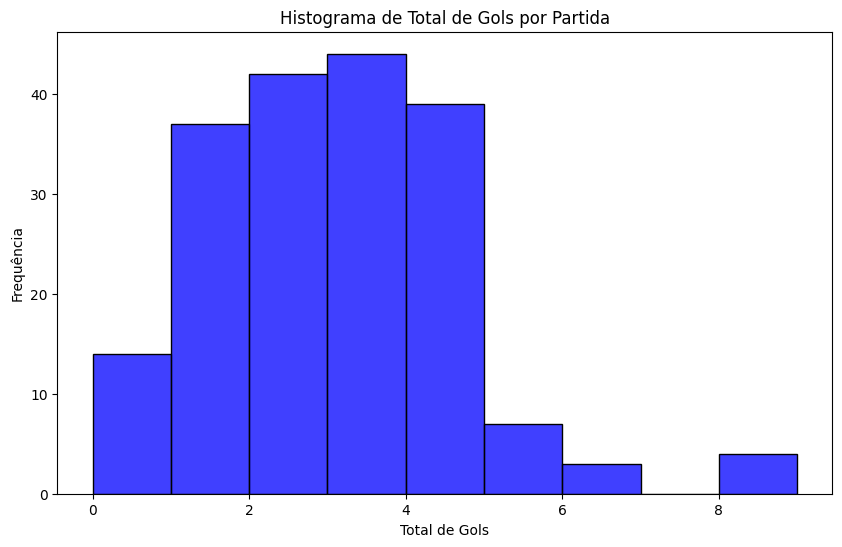

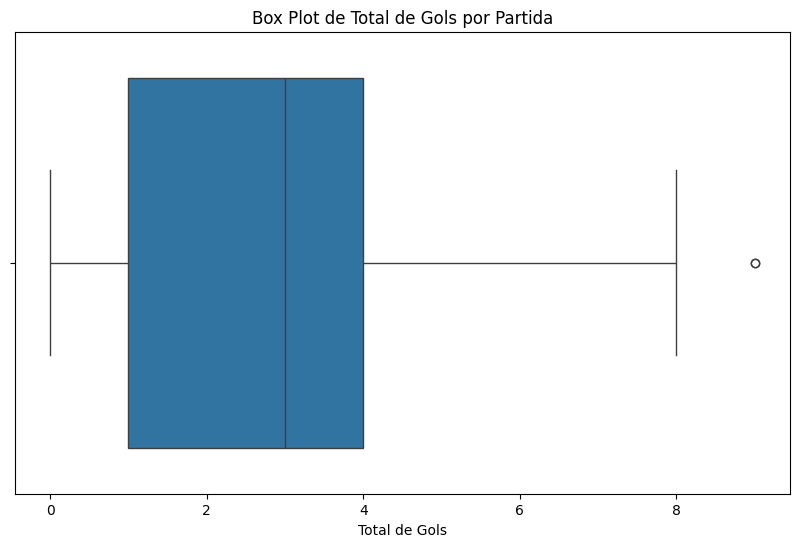

<ipython-input-30-a37cafb12795>:46: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Total_Gols'], shade=True, color='green')


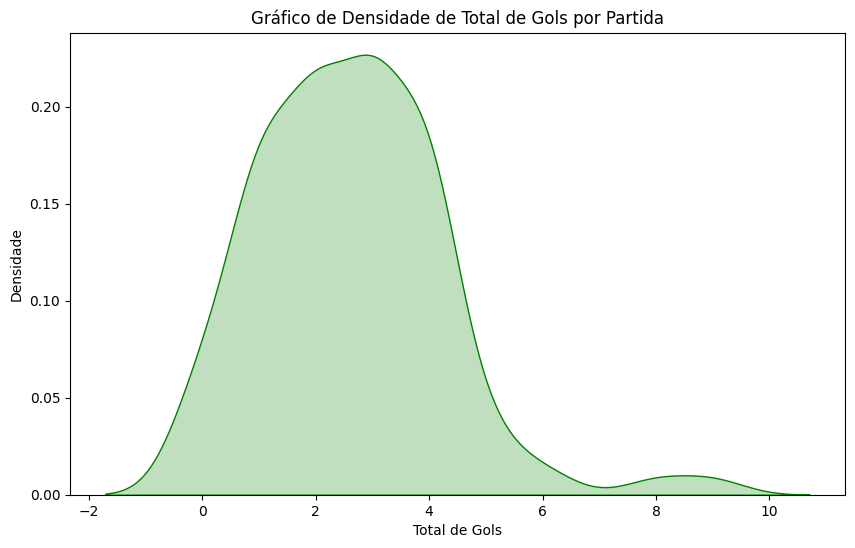

Estatística de Shapiro-Wilk: nan
Valor-p: nan
A distribuição dos dados não é normal.


In [ ]:
from scipy.stats import shapiro

# Criação de DataFrame
# Filtrando apenas as linhas pares
matches_pares = matches.iloc[::2]

# Calculando a soma dos gols realizados e gols contra
df['Total_Gols'] = matches_pares['ftg'] + matches_pares['ftga']

# df['Total_Gols'] = matches_pares['ftg'] + matches_pares['ftga']

# Análise Descritiva
media = df['Total_Gols'].mean()
mediana = df['Total_Gols'].median()
moda = df['Total_Gols'].mode()[0]
variancia = df['Total_Gols'].var()
desvio_padrao = df['Total_Gols'].std()
minimo = df['Total_Gols'].min()
maximo = df['Total_Gols'].max()

print(f"Média: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")
print(f"Variância: {variancia}")
print(f"Desvio Padrão: {desvio_padrao}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")

# Histograma
plt.figure(figsize=(10, 6))
sns.histplot(df['Total_Gols'], bins=range(0, 10), kde=False, color='blue')
plt.title('Histograma de Total de Gols por Partida')
plt.xlabel('Total de Gols')
plt.ylabel('Frequência')
plt.show()

# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Total_Gols'])
plt.title('Box Plot de Total de Gols por Partida')
plt.xlabel('Total de Gols')
plt.show()

# Gráfico de Densidade
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Total_Gols'], shade=True, color='green')
plt.title('Gráfico de Densidade de Total de Gols por Partida')
plt.xlabel('Total de Gols')
plt.ylabel('Densidade')
plt.show()

# Teste de Shapiro-Wilk
stat, p = shapiro(df['Total_Gols'])
print(f"Estatística de Shapiro-Wilk: {stat}")
print(f"Valor-p: {p}")

if p > 0.05:
    print("A distribuição dos dados é aproximadamente normal.")
else:
    print("A distribuição dos dados não é normal.")

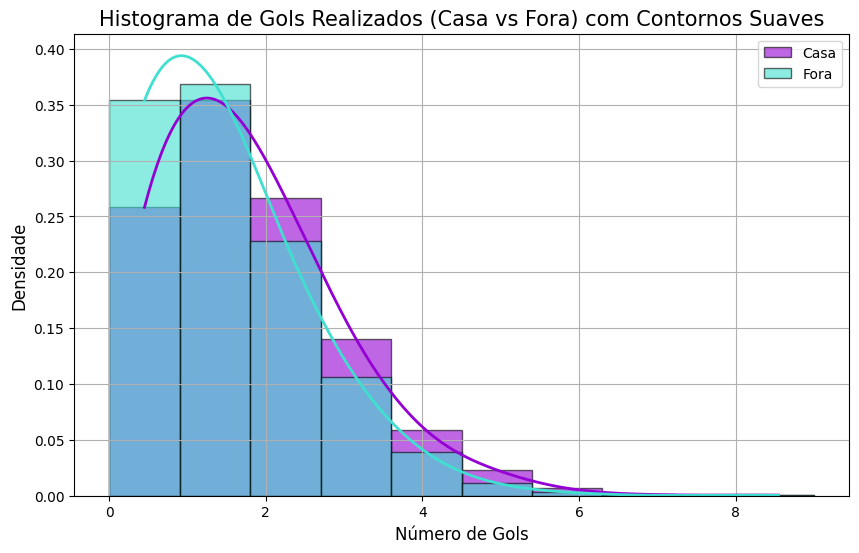

In [ ]:
from scipy.interpolate import splrep, splev

gols_realizados_home = matches[matches['venue'] == 'Home']['ftg']
gols_realizados_away = matches[matches['venue'] == 'Away']['ftg']

# Criando o histograma com contornos suaves usando matplotlib e scipy
plt.figure(figsize=(10, 6))  # Tamanho do gráfico

# Histograma para jogos em casa
count_home, bins_home, _ = plt.hist(gols_realizados_home, bins=10, alpha=0.6, color='darkviolet', edgecolor='black', label='Casa', density=True)

# Adicionando contorno ao histograma de jogos em casa
bin_centers_home = 0.5 * (bins_home[1:] + bins_home[:-1])
spl_home = splrep(bin_centers_home, count_home, s=0)
smooth_home = splev(np.linspace(bin_centers_home.min(), bin_centers_home.max(), 300), spl_home)
plt.plot(np.linspace(bin_centers_home.min(), bin_centers_home.max(), 300), smooth_home, color='darkviolet', linestyle='-', linewidth=2)

# Histograma para jogos fora de casa
count_away, bins_away, _ = plt.hist(gols_realizados_away, bins=10, alpha=0.6, color='turquoise', edgecolor='black', label='Fora', density=True)

# Adicionando contorno ao histograma de jogos fora de casa
bin_centers_away = 0.5 * (bins_away[1:] + bins_away[:-1])
spl_away = splrep(bin_centers_away, count_away, s=0)
smooth_away = splev(np.linspace(bin_centers_away.min(), bin_centers_away.max(), 300), spl_away)
plt.plot(np.linspace(bin_centers_away.min(), bin_centers_away.max(), 300), smooth_away, color='turquoise', linestyle='-', linewidth=2)

# Adicionando títulos e rótulos
plt.title('Histograma de Gols Realizados (Casa vs Fora) com Contornos Suaves', fontsize=15)
plt.xlabel('Número de Gols', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

# Adicionando a legenda
plt.legend()

# Exibindo o gráfico
plt.grid(True)
plt.show()

<ipython-input-32-1b0ad4ace327>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='venue', y='ftg', data=matches, palette=["blue", "orange"])


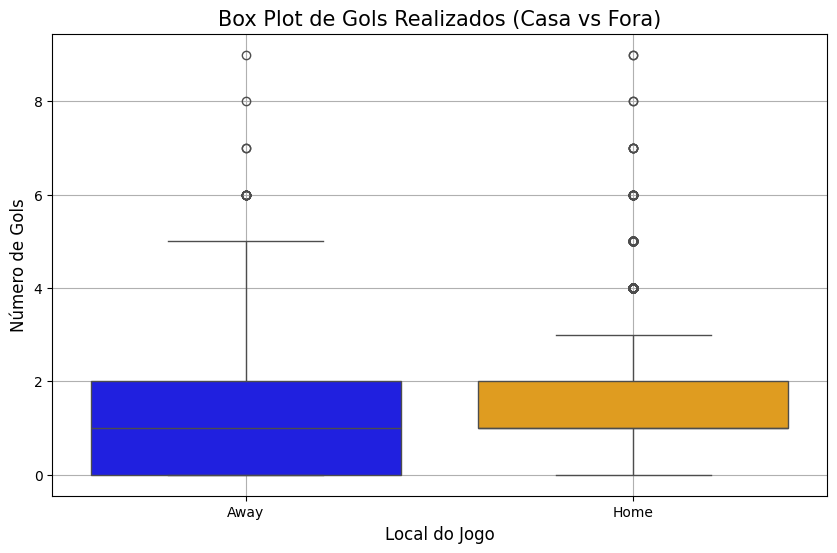

In [ ]:
plt.figure(figsize=(10, 6))  # Tamanho do gráfico

sns.boxplot(x='venue', y='ftg', data=matches, palette=["blue", "orange"])

# Adicionando títulos e rótulos
plt.title('Box Plot de Gols Realizados (Casa vs Fora)', fontsize=15)
plt.xlabel('Local do Jogo', fontsize=12)
plt.ylabel('Número de Gols', fontsize=12)

# Exibindo o gráfico
plt.grid(True)
plt.show()

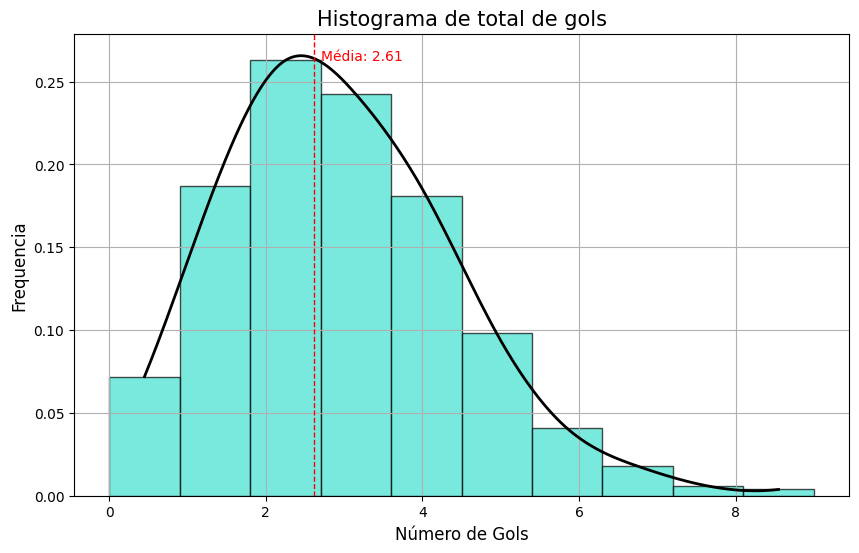

In [ ]:
# Filtrando apenas as linhas pares
matches_pares = matches.iloc[::2]

# Calculando a soma dos gols realizados e gols contra
gols_realizados = matches_pares['ftg'] + matches_pares['ftga']

# Calculando o histograma
count, bins = np.histogram(gols_realizados, bins=10, density=True)

# Calculando os centros dos bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Interpolação spline para suavizar a curva do histograma
spl = splrep(bin_centers, count)
smooth_curve = splev(np.linspace(bin_centers.min(), bin_centers.max(), 300), spl)

# Criando o histograma
plt.figure(figsize=(10, 6))
plt.hist(gols_realizados, bins=10, edgecolor='black', alpha=0.7,color='turquoise', density=True)

# Plotando a curva suave
plt.plot(np.linspace(bin_centers.min(), bin_centers.max(), 300), smooth_curve, color='black', linewidth=2)

# Adicionando a linha da média
media_gols = media
desvio_gols = np.std(gols_realizados)
plt.axvline(media_gols, color='red', linestyle='dashed', linewidth=1)
# plt.axvline(media_gols + desvio_gols, color='red', linestyle='dashed', linewidth=1)
# plt.axvline(media_gols - desvio_gols, color='red', linestyle='dashed', linewidth=1)
plt.text(media_gols + 0.1, max(count), f'Média: {media_gols:.2f}', color='red')
# plt.text(media_gols + desvio_gols + 0.1, max(count), f'Lim sup: {desvio_gols + media_gols:.2f}', color='red')
# plt.text(media_gols - desvio_gols + 0.1, max(count), f'Lim inf: {desvio_gols - media_gols:.2f}', color='red')



# Adicionando títulos e rótulos
plt.title('Histograma de total de gols', fontsize=15)
plt.xlabel('Número de Gols', fontsize=12)
plt.ylabel('Frequencia', fontsize=12)

# Exibindo o gráfico
plt.grid(True)
plt.show()

Média: 2.610526315789474
Variância: 2.6623224728487886
Estatística Qui-Quadrado: 105.50609031364543
Valor-p: 3.185354882429551e-19


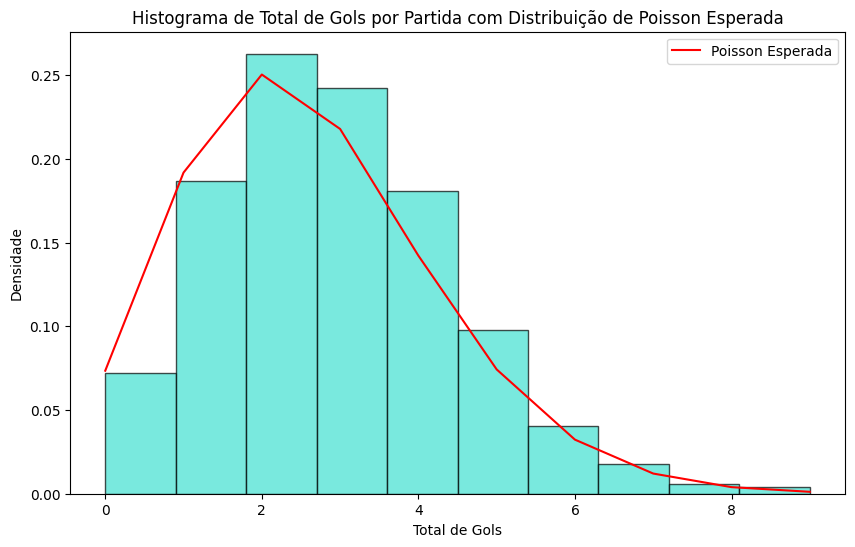

In [ ]:
from scipy.stats import poisson, chi2

# Criação de DataFrame
# Filtrando apenas as linhas pares
matches_pares = matches.iloc[::2]

# Calculando a soma dos gols realizados e gols contra
df['Total_Gols']  = matches_pares['ftg'] + matches_pares['ftga']

# Cálculo da média e variância
media = df['Total_Gols'].mean()
variancia = df['Total_Gols'].var()

print(f"Média: {media}")
print(f"Variância: {variancia}")

# Teste de Adequação Qui-Quadrado
observed_freq = df['Total_Gols'].value_counts().sort_index()
expected_freq = [poisson.pmf(i, media) * len(df) for i in observed_freq.index]

chi_square_stat = ((observed_freq - expected_freq) ** 2 / expected_freq).sum()
p_value = chi2.sf(chi_square_stat, df=len(observed_freq)-1)

print(f"Estatística Qui-Quadrado: {chi_square_stat}")
print(f"Valor-p: {p_value}")

# Plot do histograma com a distribuição de Poisson esperada
plt.figure(figsize=(10, 6))
plt.hist(gols_realizados, bins=10, edgecolor='black', alpha=0.7,color='turquoise', density=True)
# sns.histplot(df['Total_Gols'], bins=range(0, 10), kde=False, color='blue',stat='density', label='Observado')
x = np.arange(0, 10)
plt.plot(x, poisson.pmf(x, media), 'r-', label='Poisson Esperada')
plt.title('Histograma de Total de Gols por Partida com Distribuição de Poisson Esperada')
plt.xlabel('Total de Gols')
plt.ylabel('Densidade')
plt.legend()
plt.show()

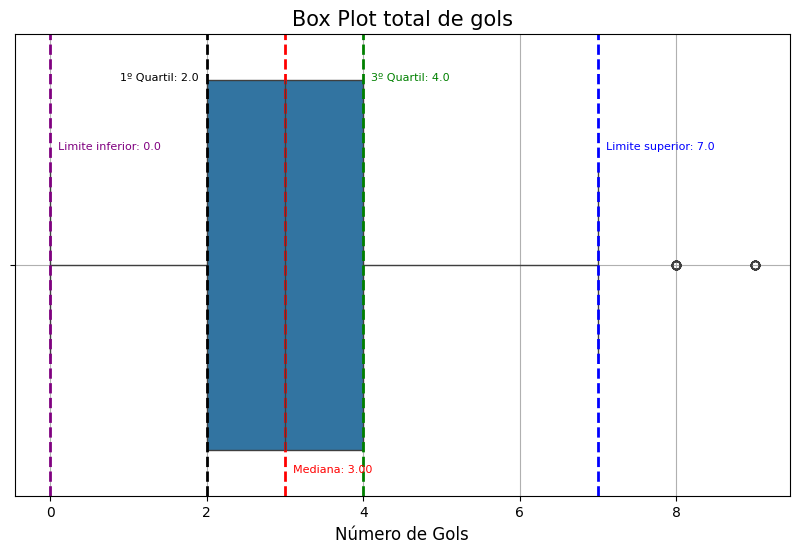

In [ ]:
tamanho_fonte = 8


# Filtrando apenas as linhas pares
matches_pares = matches.iloc[::2]

# Calculando a soma dos gols realizados e gols contra
gols_realizados = matches_pares['ftg'] + matches_pares['ftga']

# Criando o box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=gols_realizados)

# Adicionando a linha da mediana
mediana = np.median(gols_realizados)
plt.axvline(mediana, color='red', linestyle='--', linewidth=2)
plt.text(mediana + 0.1, plt.ylim()[1] * -0.9, f'Mediana: {mediana:.2f}', color='red', ha='left', fontsize=tamanho_fonte)

# Adicionando a linha do 1º Quartil
q1 = np.quantile(gols_realizados, 0.25)
plt.axvline(q1, color='black', linestyle='--', linewidth=2)
plt.text(q1 - 0.1, plt.ylim()[1] * 0.8, f'1º Quartil: {q1}', color='black', ha='right', fontsize=tamanho_fonte)

# Adicionando a linha do 3º Quartil
q3 = np.quantile(gols_realizados, 0.75)
plt.axvline(q3, color='green', linestyle='--', linewidth=2)
plt.text(q3 + 0.1, plt.ylim()[1] * 0.8, f'3º Quartil: {q3}', color='green', ha='left', fontsize=tamanho_fonte)

# Adicionando a linha do limite superior
max_boxplot = q3 + 1.5 * (q3 - q1)
plt.axvline(max_boxplot, color='blue', linestyle='--', linewidth=2)
plt.text(max_boxplot + 0.1, plt.ylim()[1] * 0.5, f'Limite superior: {max_boxplot}', color='blue', ha='left', fontsize=tamanho_fonte)

# Adicionando a linha do limite inferior
# min_boxplot = q1 - 1.5 * (q3 - q1)
min_boxplot = np.quantile(gols_realizados, 0)
plt.axvline(min_boxplot, color='purple', linestyle='--', linewidth=2)
plt.text(min_boxplot + 0.1, plt.ylim()[1] * 0.5, f'Limite inferior: {min_boxplot}', color='purple', ha='left', fontsize=tamanho_fonte)

# Adicionando títulos e rótulos
plt.title('Box Plot total de gols', fontsize=15)
plt.xlabel('Número de Gols', fontsize=12)
plt.ylabel('')

# Exibindo o gráfico
plt.grid(True)
plt.show()

In [ ]:
matches_pares = matches.iloc[::2]

# Calculando a soma dos gols realizados e gols contra
gols_realizados = matches_pares['ftg'] + matches_pares['ftga']

# Calculando a frequência absoluta
frequencia_absoluta = gols_realizados.value_counts().sort_index()

# Calculando o percentual de frequência
percentual_frequencia = (frequencia_absoluta / frequencia_absoluta.sum()) * 100

# Criando o DataFrame com os resultados
tabela_frequencia = pd.DataFrame({
    'Gols': frequencia_absoluta.index,
    'Frequencia': percentual_frequencia.values
})
tabela_frequencia['Frequencia Acumulada'] = tabela_frequencia['Frequencia'].cumsum()
tabela_frequencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gols                  10 non-null     float64
 1   Frequencia            10 non-null     float64
 2   Frequencia Acumulada  10 non-null     float64
dtypes: float64(3)
memory usage: 368.0 bytes


In [ ]:
tabela_frequencia = tabela_frequencia.round(2)
tabela_frequencia

,Gols,Frequencia,Frequencia Acumulada
0,0.0,6.47,6.47
1,1.0,16.82,23.29
2,2.0,23.66,46.95
3,3.0,21.82,68.76
4,4.0,16.29,85.05
5,5.0,8.82,93.87
6,6.0,3.66,97.53
7,7.0,1.61,99.13
8,8.0,0.53,99.66
9,9.0,0.34,100.00


We train and compare several machine learning models to predict whether a match will end with more or less than 2.5 goals:
- Logistic Regression
- Support Vector Regression (SVR)
- Random Forest

Each model is trained using the engineered features and evaluated using classification metrics.


## 7. Machine Learning Models

In [ ]:
tabela_frequencia.to_csv("tabela_frequencia_gols.csv", sep=',', index=False, encoding='utf-8')

In [ ]:
matches = matches[matches['all_gol'] <= 6]
matches = matches.reset_index(drop = True)
matches

,date,time,team,against,ftg,ftga,ftr,htg,htr,sh,...,b365<2.5,venue_code,opp_code,team_code,day_code,result,all_gol,cards_a,cards_h,guo
0,2014-08-16,NaN,Hull,QPR,1.0,0.0,1,0.0,2,11.0,...,NaN,0,23,12,5,1,1.0,1.0,2.0,0
1,2014-08-16,NaN,Crystal Palace,Arsenal,1.0,2.0,0,1.0,2,4.0,...,NaN,0,0,8,5,0,3.0,2.0,3.0,1
2,2014-08-16,NaN,Everton,Leicester,2.0,2.0,2,2.0,0,13.0,...,NaN,0,14,9,5,2,4.0,1.0,1.0,1
3,2014-08-16,NaN,Swansea,Man United,2.0,1.0,1,1.0,0,5.0,...,NaN,0,18,28,5,1,3.0,2.0,4.0,1
4,2014-08-16,NaN,Sunderland,West Brom,2.0,2.0,2,1.0,2,7.0,...,NaN,0,31,27,5,2,4.0,3.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7413,2024-05-19,16:00,Brentford,Newcastle,2.0,4.0,0,0.0,0,10.0,...,3.20,1,20,3,6,0,6.0,4.0,4.0,1
7414,2024-05-19,16:00,Arsenal,Everton,2.0,1.0,1,1.0,2,26.0,...,3.20,1,9,0,6,1,3.0,3.0,4.0,1
7415,2024-05-19,16:00,Luton,Fulham,2.0,4.0,0,1.0,0,15.0,...,2.75,1,10,16,6,0,6.0,4.0,5.0,1
7416,2024-05-19,16:00,West Ham,Man City,1.0,3.0,0,1.0,1,3.0,...,4.50,0,17,32,6,0,4.0,0.0,1.0,1


### 4.2 Transformações dos jogos que vão que acontecer

### 4.3 Criando colunas das médias dos últimos jogos

In [ ]:
predictors = ["venue_code", "team_code", "opp_code",  "day_code"]
matches[predictors]

,venue_code,team_code,opp_code,day_code
0,0,12,23,5
1,0,8,0,5
2,0,9,14,5
3,0,28,18,5
4,0,27,31,5
...,...,...,...,...
7413,1,3,20,6
7414,1,0,9,6
7415,1,16,10,6
7416,0,32,17,6


In [ ]:
matches[-50:]

,date,time,team,against,ftg,ftga,ftr,htg,htr,sh,...,b365<2.5,venue_code,opp_code,team_code,day_code,result,all_gol,cards_a,cards_h,guo
7368,2024-05-05,14:00,Aston Villa,Brighton,0.0,1.0,0,0.0,2,2.0,...,2.63,0,4,1,6,0,1.0,2.0,1.0,0
7369,2024-05-05,14:00,Chelsea,West Ham,5.0,0.0,1,3.0,1,25.0,...,3.00,1,32,7,6,1,5.0,3.0,1.0,1
7370,2024-05-06,20:00,Man United,Crystal Palace,0.0,4.0,0,0.0,1,7.0,...,2.50,0,8,18,0,0,4.0,1.0,1.0,1
7371,2024-05-06,20:00,Crystal Palace,Man United,4.0,0.0,1,2.0,1,18.0,...,2.50,1,18,8,0,1,4.0,1.0,1.0,1
7372,2024-05-11,15:00,West Ham,Luton,3.0,1.0,1,0.0,0,24.0,...,2.75,1,16,32,5,1,4.0,3.0,1.0,1
7373,2024-05-11,15:00,Wolves,Crystal Palace,1.0,3.0,0,0.0,0,13.0,...,2.00,1,8,33,5,0,4.0,3.0,3.0,1
7374,2024-05-11,15:00,Everton,Sheffield United,1.0,0.0,1,1.0,1,15.0,...,2.50,1,24,9,5,1,1.0,2.0,1.0,0
7375,2024-05-11,15:00,Bournemouth,Brentford,1.0,2.0,0,0.0,2,13.0,...,2.75,1,3,2,5,0,3.0,2.0,2.0,1
7376,2024-05-11,12:30,Fulham,Man City,0.0,4.0,0,0.0,0,1.0,...,3.20,1,17,10,5,0,4.0,0.0,2.0,1
7377,2024-05-11,15:00,Newcastle,Brighton,1.0,1.0,2,1.0,2,18.0,...,3.40,1,4,20,5,2,2.0,4.0,3.0,0


In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        7418 non-null   datetime64[ns]
 1   time        3692 non-null   object        
 2   team        7418 non-null   object        
 3   against     7418 non-null   object        
 4   ftg         7418 non-null   float64       
 5   ftga        7418 non-null   float64       
 6   ftr         7418 non-null   int64         
 7   htg         7418 non-null   float64       
 8   htr         7418 non-null   int64         
 9   sh          7418 non-null   float64       
 10  sa          7418 non-null   float64       
 11  sth         7418 non-null   float64       
 12  sta         7418 non-null   float64       
 13  fh          7418 non-null   float64       
 14  fa          7418 non-null   float64       
 15  ch          7418 non-null   float64       
 16  ca          7418 non-nul

In [ ]:
matches = matches[["date","team","against","ftg","ftga","ftr","points","season","venue_code","opp_code","team_code","day_code","all_gol", 'guo','b365>2.5', 'b365<2.5']]
matches_home = matches[matches['venue_code'] == 1]
matches_away = matches[matches['venue_code'] == 0]

In [ ]:
grouped_matches = matches_home.groupby("team")
lista_team = matches_home['team'].unique().tolist()
lista_anos = list(range(2024, 2014, -1))
all_matches = []


for i in lista_team:
  group = grouped_matches.get_group(i).sort_values("date")
  for j in lista_anos:
    group_teste = group[group['season'] == j]
    group_teste = group_teste.reset_index()
    group_teste['gols_acc_venue'] = group_teste['ftg'].shift(1).cumsum(axis = 0)
    group_teste['gols_against_acc_venue'] = group_teste['ftga'].shift(1).cumsum(axis = 0)
    group_teste['ftg_max_venue'] = group_teste['ftg'].shift().cummax(axis = 0)
    group_teste['ftg_min_venue'] = group_teste['ftg'].shift().cummin(axis = 0)
    group_teste['games_venue'] = 1
    group_teste['qnt_jogos_venue'] = group_teste['games_venue'].shift(1).cumsum(axis = 0)
    group_teste['ftg_mean_venue'] = group_teste['gols_acc_venue']/group_teste['qnt_jogos_venue']
    group_teste['ftga_mean_venue'] = group_teste['gols_against_acc_venue']/group_teste['qnt_jogos_venue']
    group_teste['ftg_std_venue'] = group_teste['ftg'].expanding().std()
    group_teste['ftga_std_venue'] = group_teste['ftga'].expanding().std()
    all_matches.append(group_teste)
  # group.append(group)
matches_rolling_home = pd.concat(all_matches)
matches_rolling_home.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3709 entries, 0 to 17
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   index                   3709 non-null   int64         
 1   date                    3709 non-null   datetime64[ns]
 2   team                    3709 non-null   object        
 3   against                 3709 non-null   object        
 4   ftg                     3709 non-null   float64       
 5   ftga                    3709 non-null   float64       
 6   ftr                     3709 non-null   int64         
 7   points                  3709 non-null   int64         
 8   season                  3709 non-null   int64         
 9   venue_code              3709 non-null   int8          
 10  opp_code                3709 non-null   int8          
 11  team_code               3709 non-null   int8          
 12  day_code                3709 non-null   int32         


In [ ]:
grouped_matches = matches_away.groupby("team")
lista_team = matches_away['team'].unique().tolist()
lista_anos = list(range(2024, 2014, -1))
all_matches = []

for i in lista_team:
  group = grouped_matches.get_group(i).sort_values("date")
  for j in lista_anos:
    group_teste = group[group['season'] == j]
    group_teste = group_teste.reset_index()
    group_teste['gols_acc_venue'] = group_teste['ftg'].shift(1).cumsum(axis = 0)
    group_teste['gols_against_acc_venue'] = group_teste['ftga'].shift(1).cumsum(axis = 0)
    group_teste['ftg_max_venue'] = group_teste['ftg'].shift().cummax(axis = 0)
    group_teste['ftg_min_venue'] = group_teste['ftg'].shift().cummin(axis = 0)
    group_teste['games_venue'] = 1
    group_teste['qnt_jogos_venue'] = group_teste['games_venue'].shift(1).cumsum(axis = 0)
    group_teste['ftg_mean_venue'] = group_teste['gols_acc_venue']/group_teste['qnt_jogos_venue']
    group_teste['ftga_mean_venue'] = group_teste['gols_against_acc_venue']/group_teste['qnt_jogos_venue']
    group_teste['ftg_std_venue'] = group_teste['ftg'].expanding().std()
    group_teste['ftga_std_venue'] = group_teste['ftga'].expanding().std()
    all_matches.append(group_teste)
  # group.append(group)
matches_rolling_away = pd.concat(all_matches)
matches_rolling_away.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3709 entries, 0 to 16
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   index                   3709 non-null   int64         
 1   date                    3709 non-null   datetime64[ns]
 2   team                    3709 non-null   object        
 3   against                 3709 non-null   object        
 4   ftg                     3709 non-null   float64       
 5   ftga                    3709 non-null   float64       
 6   ftr                     3709 non-null   int64         
 7   points                  3709 non-null   int64         
 8   season                  3709 non-null   int64         
 9   venue_code              3709 non-null   int8          
 10  opp_code                3709 non-null   int8          
 11  team_code               3709 non-null   int8          
 12  day_code                3709 non-null   int32         


In [ ]:
matches_full = pd.concat([matches_rolling_home, matches_rolling_away], ignore_index=True)
matches_full = matches_full.sort_values(by = 'date', ascending = False).reset_index(drop = True)
matches_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   index                   7418 non-null   int64         
 1   date                    7418 non-null   datetime64[ns]
 2   team                    7418 non-null   object        
 3   against                 7418 non-null   object        
 4   ftg                     7418 non-null   float64       
 5   ftga                    7418 non-null   float64       
 6   ftr                     7418 non-null   int64         
 7   points                  7418 non-null   int64         
 8   season                  7418 non-null   int64         
 9   venue_code              7418 non-null   int8          
 10  opp_code                7418 non-null   int8          
 11  team_code               7418 non-null   int8          
 12  day_code                7418 non-null   int32   

In [ ]:
matches_full['gols_acc_venue'] = matches_full['gols_acc_venue'].fillna(0)
matches_full['gols_against_acc_venue'] = matches_full['gols_against_acc_venue'].fillna(0)
matches_full['ftg_max_venue'] = matches_full['ftg_max_venue'].fillna(0)
matches_full['ftg_min_venue'] = matches_full['ftg_min_venue'].fillna(0)
matches_full['qnt_jogos_venue'] = matches_full['qnt_jogos_venue'].fillna(0)
matches_full['ftg_mean_venue'] = matches_full['ftg_mean_venue'].fillna(0)
matches_full['ftga_mean_venue'] = matches_full['ftga_mean_venue'].fillna(0)
matches_full['ftg_std_venue'] = matches_full['ftg_std_venue'].fillna(0)

matches_full['ftg_max_venue'] = matches_full['ftg_max_venue'].fillna(matches_full['ftg_mean_venue'])
matches_full['ftg_min_venue'] = matches_full['ftg_min_venue'].fillna(matches_full['ftg_mean_venue'])
matches_full['ftg_std_venue'] = matches_full['ftg_std_venue'].fillna(0)
matches_full['ftga_std_venue'] = matches_full['ftga_std_venue'].fillna(0)

matches_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   index                   7418 non-null   int64         
 1   date                    7418 non-null   datetime64[ns]
 2   team                    7418 non-null   object        
 3   against                 7418 non-null   object        
 4   ftg                     7418 non-null   float64       
 5   ftga                    7418 non-null   float64       
 6   ftr                     7418 non-null   int64         
 7   points                  7418 non-null   int64         
 8   season                  7418 non-null   int64         
 9   venue_code              7418 non-null   int8          
 10  opp_code                7418 non-null   int8          
 11  team_code               7418 non-null   int8          
 12  day_code                7418 non-null   int32   

In [ ]:
grouped_matches = matches_full.groupby("team")
lista_team = matches['team'].unique().tolist()
lista_anos = list(range(2024, 2014, -1))
all_matches = []


for i in lista_team:
  group = grouped_matches.get_group(i).sort_values("date")
  for j in lista_anos:
    group_teste = group[group['season'] == j]
    group_teste = group_teste.reset_index()
    group_teste['points_camp'] = group_teste['points'].shift(1).cumsum(axis = 0)
    group_teste['gols_acc'] = group_teste['ftg'].shift(1).cumsum(axis = 0)
    group_teste['gols_against_acc'] = group_teste['ftga'].shift(1).cumsum(axis = 0)
    group_teste['ftg_max'] = group_teste['ftg'].shift().cummax(axis = 0)
    group_teste['ftg_min'] = group_teste['ftg'].shift().cummin(axis = 0)
    group_teste['games'] = 1
    group_teste['qnt_jogos'] = group_teste['games'].shift(1).cumsum(axis = 0)
    group_teste['ftg_mean'] = group_teste['gols_acc']/group_teste['qnt_jogos']
    group_teste['ftga_mean'] = group_teste['gols_against_acc']/group_teste['qnt_jogos']
    group_teste['ftg_std'] = group_teste['ftg'].expanding().std()
    group_teste['ftga_std'] = group_teste['ftga'].expanding().std()
    all_matches.append(group_teste)

In [ ]:
matches_rolling = pd.concat(all_matches)
matches_rolling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7418 entries, 0 to 34
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   level_0                 7418 non-null   int64         
 1   index                   7418 non-null   int64         
 2   date                    7418 non-null   datetime64[ns]
 3   team                    7418 non-null   object        
 4   against                 7418 non-null   object        
 5   ftg                     7418 non-null   float64       
 6   ftga                    7418 non-null   float64       
 7   ftr                     7418 non-null   int64         
 8   points                  7418 non-null   int64         
 9   season                  7418 non-null   int64         
 10  venue_code              7418 non-null   int8          
 11  opp_code                7418 non-null   int8          
 12  team_code               7418 non-null   int8          


In [ ]:
matches_rolling['points_camp'] = matches_rolling['points_camp'].fillna(0)
matches_rolling['gols_acc'] = matches_rolling['gols_acc'].fillna(0)
matches_rolling['gols_against_acc'] = matches_rolling['gols_against_acc'].fillna(0)
matches_rolling['ftg_max'] = matches_rolling['ftg_max'].fillna(0)
matches_rolling['ftg_min'] = matches_rolling['ftg_min'].fillna(0)
matches_rolling['games'] = matches_rolling['games'].fillna(0)
matches_rolling['qnt_jogos'] = matches_rolling['qnt_jogos'].fillna(0)
matches_rolling['ftg_mean'] = matches_rolling['ftg_mean'].fillna(0)
matches_rolling['ftga_mean'] = matches_rolling['ftga_mean'].fillna(0)
matches_rolling['ftg_std'] = matches_rolling['ftg_std'].fillna(0)
matches_rolling['ftga_std'] = matches_rolling['ftga_std'].fillna(0)
matches_rolling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7418 entries, 0 to 34
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   level_0                 7418 non-null   int64         
 1   index                   7418 non-null   int64         
 2   date                    7418 non-null   datetime64[ns]
 3   team                    7418 non-null   object        
 4   against                 7418 non-null   object        
 5   ftg                     7418 non-null   float64       
 6   ftga                    7418 non-null   float64       
 7   ftr                     7418 non-null   int64         
 8   points                  7418 non-null   int64         
 9   season                  7418 non-null   int64         
 10  venue_code              7418 non-null   int8          
 11  opp_code                7418 non-null   int8          
 12  team_code               7418 non-null   int8          


In [ ]:
matches_rolling

,level_0,index,date,team,against,ftg,ftga,ftr,points,season,...,gols_acc,gols_against_acc,ftg_max,ftg_min,games,qnt_jogos,ftg_mean,ftga_mean,ftg_std,ftga_std
0,5916,1503,2016-08-13,Hull,Leicester,2.0,1.0,1,3,2017,...,0.0,0.0,0.0,0.0,1,0.0,0.000000,0.000000,0.000000,0.000000
1,5905,1516,2016-08-20,Hull,Swansea,2.0,0.0,1,3,2017,...,2.0,1.0,2.0,2.0,1,1.0,2.000000,1.000000,0.000000,0.707107
2,5880,1540,2016-08-27,Hull,Man United,0.0,1.0,0,1,2017,...,4.0,1.0,2.0,2.0,1,2.0,2.000000,0.500000,1.154701,0.577350
3,5857,1562,2016-09-10,Hull,Burnley,1.0,1.0,2,0,2017,...,4.0,2.0,2.0,0.0,1,3.0,1.333333,0.666667,0.957427,0.500000
4,5840,1579,2016-09-17,Hull,Arsenal,1.0,4.0,0,1,2017,...,5.0,3.0,2.0,0.0,1,4.0,1.250000,0.750000,0.836660,1.516575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,108,7306,2024-04-20,Luton,Brentford,1.0,5.0,0,1,2024,...,36.0,58.0,4.0,0.0,1,30.0,1.200000,1.933333,0.872520,1.303428
31,74,7332,2024-04-27,Luton,Wolves,1.0,2.0,0,1,2024,...,37.0,63.0,4.0,0.0,1,31.0,1.193548,2.032258,0.859013,1.282245
32,64,7352,2024-05-03,Luton,Everton,1.0,1.0,2,0,2024,...,38.0,65.0,4.0,0.0,1,32.0,1.187500,2.031250,0.846114,1.274755
33,36,7384,2024-05-11,Luton,West Ham,1.0,3.0,0,1,2024,...,39.0,66.0,4.0,0.0,1,33.0,1.181818,2.000000,0.833779,1.266953


In [ ]:
grouped_matches = matches_rolling.groupby("team")
lista_team = matches_rolling['team'].unique().tolist()
lista_anos = list(range(2024, 2014, -1))
all_matches = []

for team in lista_team:
    group = grouped_matches.get_group(team).sort_values("date")
    for year in lista_anos:
        group_year = group[group['season'] == year].reset_index(drop=True)
        for window_size in range(1, 8):  # Loop de 1 a 7 para calcular as médias das últimas 1 a 7 partidas
            # Calcula a média dos gols feitos nas últimas partidas excluindo a linha atual
            group_year[f'media_gols_feitos_ultimas_{window_size}_partidas'] = group_year['ftg'].shift(1).rolling(window=window_size, min_periods=1).mean()
            # Calcula a média dos gols sofridos nas últimas partidas excluindo a linha atual
            group_year[f'media_gols_sofridos_ultimas_{window_size}_partidas'] = group_year['ftga'].shift(1).rolling(window=window_size, min_periods=1).mean()
        all_matches.append(group_year)

matches_rolling = pd.concat(all_matches)

filtro = (matches_rolling['team'] == "Everton") & (matches_rolling['season'] == 2024)
df_filtrado = matches_rolling[filtro].reset_index(drop=True)

In [ ]:
df_filtrado[['date', 'team', 'against', 'ftg', 'ftga', 'media_gols_feitos_ultimas_3_partidas', 'media_gols_sofridos_ultimas_3_partidas']]

,date,team,against,ftg,ftga,media_gols_feitos_ultimas_3_partidas,media_gols_sofridos_ultimas_3_partidas
0,2023-08-12,Everton,Fulham,0.0,1.0,NaN,NaN
1,2023-08-20,Everton,Aston Villa,0.0,4.0,0.000000,1.000000
2,2023-08-26,Everton,Wolves,0.0,1.0,0.000000,2.500000
3,2023-09-02,Everton,Sheffield United,2.0,2.0,0.000000,2.000000
4,2023-09-17,Everton,Arsenal,0.0,1.0,0.666667,2.333333
5,2023-09-23,Everton,Brentford,3.0,1.0,0.666667,1.333333
6,2023-09-30,Everton,Luton,1.0,2.0,1.666667,1.333333
7,2023-10-07,Everton,Bournemouth,3.0,0.0,1.333333,1.333333
8,2023-10-21,Everton,Liverpool,0.0,2.0,2.333333,1.000000
9,2023-10-29,Everton,West Ham,1.0,0.0,1.333333,1.333333


In [ ]:
matches_rolling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7418 entries, 0 to 34
Data columns (total 53 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   level_0                                 7418 non-null   int64         
 1   index                                   7418 non-null   int64         
 2   date                                    7418 non-null   datetime64[ns]
 3   team                                    7418 non-null   object        
 4   against                                 7418 non-null   object        
 5   ftg                                     7418 non-null   float64       
 6   ftga                                    7418 non-null   float64       
 7   ftr                                     7418 non-null   int64         
 8   points                                  7418 non-null   int64         
 9   season                                  7418 non-null   int

In [ ]:
 matches_rolling['media_gols_feitos_ultimas_1_partidas'] = matches_rolling['media_gols_feitos_ultimas_1_partidas'].fillna(0)
 matches_rolling['media_gols_sofridos_ultimas_1_partidas'] = matches_rolling['media_gols_sofridos_ultimas_1_partidas'].fillna(0)
 matches_rolling['media_gols_feitos_ultimas_2_partidas'] = matches_rolling['media_gols_feitos_ultimas_2_partidas'].fillna(0)
 matches_rolling['media_gols_sofridos_ultimas_2_partidas'] = matches_rolling['media_gols_sofridos_ultimas_2_partidas'].fillna(0)
 matches_rolling['media_gols_feitos_ultimas_3_partidas'] = matches_rolling['media_gols_feitos_ultimas_3_partidas'].fillna(0)
 matches_rolling['media_gols_sofridos_ultimas_3_partidas'] = matches_rolling['media_gols_sofridos_ultimas_3_partidas'].fillna(0)
 matches_rolling['media_gols_feitos_ultimas_4_partidas'] = matches_rolling['media_gols_feitos_ultimas_4_partidas'].fillna(0)
 matches_rolling['media_gols_sofridos_ultimas_4_partidas'] = matches_rolling['media_gols_sofridos_ultimas_4_partidas'].fillna(0)
 matches_rolling['media_gols_feitos_ultimas_5_partidas'] = matches_rolling['media_gols_feitos_ultimas_5_partidas'].fillna(0)
 matches_rolling['media_gols_sofridos_ultimas_5_partidas'] = matches_rolling['media_gols_sofridos_ultimas_5_partidas'].fillna(0)
 matches_rolling['media_gols_feitos_ultimas_6_partidas'] = matches_rolling['media_gols_feitos_ultimas_6_partidas'].fillna(0)
 matches_rolling['media_gols_sofridos_ultimas_6_partidas'] = matches_rolling['media_gols_sofridos_ultimas_6_partidas'].fillna(0)
 matches_rolling['media_gols_feitos_ultimas_7_partidas'] = matches_rolling['media_gols_feitos_ultimas_7_partidas'].fillna(0)
 matches_rolling['media_gols_sofridos_ultimas_7_partidas'] = matches_rolling['media_gols_sofridos_ultimas_7_partidas'].fillna(0)
 matches_rolling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7418 entries, 0 to 34
Data columns (total 53 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   level_0                                 7418 non-null   int64         
 1   index                                   7418 non-null   int64         
 2   date                                    7418 non-null   datetime64[ns]
 3   team                                    7418 non-null   object        
 4   against                                 7418 non-null   object        
 5   ftg                                     7418 non-null   float64       
 6   ftga                                    7418 non-null   float64       
 7   ftr                                     7418 non-null   int64         
 8   points                                  7418 non-null   int64         
 9   season                                  7418 non-null   int

In [ ]:
matches_rolling = matches_rolling.reset_index(drop = True)
matches_rolling

,level_0,index,date,team,against,ftg,ftga,ftr,points,season,...,media_gols_feitos_ultimas_3_partidas,media_gols_sofridos_ultimas_3_partidas,media_gols_feitos_ultimas_4_partidas,media_gols_sofridos_ultimas_4_partidas,media_gols_feitos_ultimas_5_partidas,media_gols_sofridos_ultimas_5_partidas,media_gols_feitos_ultimas_6_partidas,media_gols_sofridos_ultimas_6_partidas,media_gols_feitos_ultimas_7_partidas,media_gols_sofridos_ultimas_7_partidas
0,5916,1503,2016-08-13,Hull,Leicester,2.0,1.0,1,3,2017,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,5905,1516,2016-08-20,Hull,Swansea,2.0,0.0,1,3,2017,...,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000
2,5880,1540,2016-08-27,Hull,Man United,0.0,1.0,0,1,2017,...,2.000000,0.500000,2.000000,0.500000,2.000000,0.500000,2.000000,0.500000,2.000000,0.500000
3,5857,1562,2016-09-10,Hull,Burnley,1.0,1.0,2,0,2017,...,1.333333,0.666667,1.333333,0.666667,1.333333,0.666667,1.333333,0.666667,1.333333,0.666667
4,5840,1579,2016-09-17,Hull,Arsenal,1.0,4.0,0,1,2017,...,1.000000,0.666667,1.250000,0.750000,1.250000,0.750000,1.250000,0.750000,1.250000,0.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7413,108,7306,2024-04-20,Luton,Brentford,1.0,5.0,0,1,2024,...,1.000000,2.666667,1.000000,2.500000,1.000000,2.200000,1.000000,2.000000,1.142857,2.142857
7414,74,7332,2024-04-27,Luton,Wolves,1.0,2.0,0,1,2024,...,1.333333,3.666667,1.000000,3.250000,1.000000,3.000000,1.000000,2.666667,1.000000,2.428571
7415,64,7352,2024-05-03,Luton,Everton,1.0,1.0,2,0,2024,...,1.000000,4.000000,1.250000,3.250000,1.000000,3.000000,1.000000,2.833333,1.000000,2.571429
7416,36,7384,2024-05-11,Luton,West Ham,1.0,3.0,0,1,2024,...,1.000000,2.666667,1.000000,3.250000,1.200000,2.800000,1.000000,2.666667,1.000000,2.571429


In [ ]:
matches_rolling = matches_rolling.sort_values(['date'], ascending = [True]).reset_index(drop = True)
matches_rolling[-50:]

,level_0,index,date,team,against,ftg,ftga,ftr,points,season,...,media_gols_feitos_ultimas_3_partidas,media_gols_sofridos_ultimas_3_partidas,media_gols_feitos_ultimas_4_partidas,media_gols_sofridos_ultimas_4_partidas,media_gols_feitos_ultimas_5_partidas,media_gols_sofridos_ultimas_5_partidas,media_gols_feitos_ultimas_6_partidas,media_gols_sofridos_ultimas_6_partidas,media_gols_feitos_ultimas_7_partidas,media_gols_sofridos_ultimas_7_partidas
7368,53,7364,2024-05-05,Liverpool,Tottenham,4.0,2.0,1,3,2024,...,1.666667,1.666667,1.25,1.50,1.4,1.6,1.666667,1.500000,1.714286,1.428571
7369,52,7367,2024-05-05,West Ham,Chelsea,0.0,5.0,0,1,2024,...,1.333333,1.666667,1.25,1.50,1.2,1.4,1.333333,1.500000,1.571429,1.428571
7370,47,7370,2024-05-06,Man United,Crystal Palace,0.0,4.0,0,1,2024,...,2.333333,1.666667,2.25,1.75,2.0,1.6,2.000000,1.333333,1.857143,1.571429
7371,46,7371,2024-05-06,Crystal Palace,Man United,4.0,0.0,1,3,2024,...,1.333333,0.333333,1.50,1.25,1.2,1.2,1.166667,1.166667,1.142857,1.142857
7372,43,7373,2024-05-11,Wolves,Crystal Palace,1.0,3.0,0,1,2024,...,1.000000,2.333333,0.75,2.25,1.0,2.2,1.000000,2.166667,1.000000,2.000000
7373,45,7376,2024-05-11,Fulham,Man City,0.0,4.0,0,1,2024,...,0.666667,1.333333,1.00,1.00,0.8,1.0,0.833333,1.333333,1.142857,1.571429
7374,32,7381,2024-05-11,Man City,Fulham,4.0,0.0,1,3,2024,...,3.666667,0.333333,4.00,0.50,4.0,0.8,4.000000,0.833333,3.428571,0.714286
7375,42,7385,2024-05-11,Chelsea,Nott'm Forest,3.0,2.0,1,3,2024,...,3.000000,0.666667,2.25,1.75,3.0,1.4,2.833333,1.500000,2.714286,1.571429
7376,30,7374,2024-05-11,Everton,Sheffield United,1.0,0.0,1,3,2024,...,1.333333,0.333333,1.50,0.25,1.2,1.4,1.166667,1.166667,1.142857,1.142857
7377,39,7378,2024-05-11,Tottenham,Burnley,2.0,1.0,1,3,2024,...,1.333333,3.000000,1.00,3.25,1.4,2.8,1.333333,2.500000,1.428571,2.285714


In [ ]:
import string
alphabet = list(string.ascii_uppercase)
lista_temporaria = []

for i in range(len(matches_rolling)):
  for j in range(len(alphabet)):
    if matches_rolling['team'][i][0] ==  alphabet[j]:
      team_num = j
    if matches_rolling['against'][i][0] ==  alphabet[j]:
      againt_num = j
  if team_num < againt_num:
    lista_temporaria.append(matches_rolling['team'][i] + '-' + matches_rolling['against'][i])
  else:
    lista_temporaria.append(matches_rolling['against'][i] + '-' + matches_rolling['team'][i])

matches_rolling["chave"] = lista_temporaria

matches_rolling = matches_rolling.sort_values(['date', 'chave'], ascending = [True, True]).reset_index(drop = True)
matches_rolling

,level_0,index,date,team,against,ftg,ftga,ftr,points,season,...,media_gols_sofridos_ultimas_3_partidas,media_gols_feitos_ultimas_4_partidas,media_gols_sofridos_ultimas_4_partidas,media_gols_feitos_ultimas_5_partidas,media_gols_sofridos_ultimas_5_partidas,media_gols_feitos_ultimas_6_partidas,media_gols_sofridos_ultimas_6_partidas,media_gols_feitos_ultimas_7_partidas,media_gols_sofridos_ultimas_7_partidas,chave
0,7415,1,2014-08-16,Crystal Palace,Arsenal,1.0,2.0,0,1,2015,...,0.000000,0.00,0.00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Arsenal-Crystal Palace
1,7407,11,2014-08-16,Arsenal,Crystal Palace,2.0,1.0,1,3,2015,...,0.000000,0.00,0.00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Arsenal-Crystal Palace
2,7411,5,2014-08-16,Aston Villa,Stoke,1.0,0.0,1,3,2015,...,0.000000,0.00,0.00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Aston Villa-Stoke
3,7414,10,2014-08-16,Stoke,Aston Villa,0.0,1.0,0,1,2015,...,0.000000,0.00,0.00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Aston Villa-Stoke
4,7412,2,2014-08-16,Everton,Leicester,2.0,2.0,2,0,2015,...,0.000000,0.00,0.00,0.0,0.0,0.000000,0.000000,0.000000,0.000000,Everton-Leicester
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7413,17,7407,2024-05-19,Liverpool,Wolves,2.0,0.0,1,3,2024,...,2.333333,2.25,2.25,2.4,2.0,2.000000,1.833333,2.000000,1.857143,Liverpool-Wolves
7414,15,7401,2024-05-19,Man City,West Ham,3.0,1.0,1,3,2024,...,0.333333,3.25,0.25,3.4,0.2,3.666667,0.333333,3.714286,0.571429,Man City-West Ham
7415,14,7416,2024-05-19,West Ham,Man City,1.0,3.0,0,1,2024,...,2.666667,1.25,2.50,1.4,2.2,1.333333,2.000000,1.285714,1.857143,Man City-West Ham
7416,9,7408,2024-05-19,Tottenham,Sheffield United,3.0,0.0,1,3,2024,...,2.333333,1.00,2.25,1.2,2.4,1.000000,2.666667,1.285714,2.428571,Sheffield United-Tottenham


In [ ]:
df_pares= matches_rolling[matches_rolling['venue_code'] == 0]  # índices pares
df_impares = matches_rolling[matches_rolling['venue_code'] == 1]   # índices ímpares

df_pares_sel = df_pares[['ftg_mean','ftga_mean','ftg_mean_venue','ftga_mean_venue','media_gols_feitos_ultimas_1_partidas','media_gols_sofridos_ultimas_1_partidas',
'media_gols_feitos_ultimas_2_partidas','media_gols_sofridos_ultimas_2_partidas','media_gols_feitos_ultimas_3_partidas','media_gols_sofridos_ultimas_3_partidas',
'media_gols_feitos_ultimas_4_partidas','media_gols_sofridos_ultimas_4_partidas','media_gols_feitos_ultimas_5_partidas','media_gols_sofridos_ultimas_5_partidas',
'media_gols_feitos_ultimas_6_partidas','media_gols_sofridos_ultimas_6_partidas','media_gols_feitos_ultimas_7_partidas','media_gols_sofridos_ultimas_7_partidas']]
df_impares_sel = df_impares[['ftg_mean','ftga_mean','ftg_mean_venue','ftga_mean_venue','media_gols_feitos_ultimas_1_partidas','media_gols_sofridos_ultimas_1_partidas',
'media_gols_feitos_ultimas_2_partidas','media_gols_sofridos_ultimas_2_partidas','media_gols_feitos_ultimas_3_partidas','media_gols_sofridos_ultimas_3_partidas',
'media_gols_feitos_ultimas_4_partidas','media_gols_sofridos_ultimas_4_partidas','media_gols_feitos_ultimas_5_partidas','media_gols_sofridos_ultimas_5_partidas',
'media_gols_feitos_ultimas_6_partidas','media_gols_sofridos_ultimas_6_partidas','media_gols_feitos_ultimas_7_partidas','media_gols_sofridos_ultimas_7_partidas']]

# df_pares_sel = df_pares[['ftga_mean','ftga_mean_venue','media_gols_sofridos_ultimas_1_partidas','media_gols_sofridos_ultimas_2_partidas',
# 'media_gols_sofridos_ultimas_3_partidas','media_gols_sofridos_ultimas_4_partidas','media_gols_sofridos_ultimas_5_partidas',
# 'media_gols_sofridos_ultimas_6_partidas','media_gols_sofridos_ultimas_7_partidas']]
# df_impares_sel = df_impares[['ftga_mean','ftga_mean_venue','media_gols_sofridos_ultimas_1_partidas','media_gols_sofridos_ultimas_2_partidas',
# 'media_gols_sofridos_ultimas_3_partidas','media_gols_sofridos_ultimas_4_partidas','media_gols_sofridos_ultimas_5_partidas',
# 'media_gols_sofridos_ultimas_6_partidas','media_gols_sofridos_ultimas_7_partidas']]

df_pares_sel = df_pares_sel.reset_index(drop = True)
df_impares_sel = df_impares_sel.reset_index(drop = True)

df_pares=  df_pares.reset_index(drop = True) # índices pares
df_impares = df_impares.reset_index(drop = True)  # índices ímpares

df_pares_sel = df_pares_sel.add_suffix('_against')
df_impares_sel = df_impares_sel.add_suffix('_against')

matches_rolling_1 = pd.concat([df_pares, df_impares_sel], axis=1)
matches_rolling_2 = pd.concat([df_impares, df_pares_sel], axis=1)
matches_rolling = pd.concat([matches_rolling_1, matches_rolling_2], axis=0, ignore_index=True)
matches_rolling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 72 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   level_0                                         7418 non-null   int64         
 1   index                                           7418 non-null   int64         
 2   date                                            7418 non-null   datetime64[ns]
 3   team                                            7418 non-null   object        
 4   against                                         7418 non-null   object        
 5   ftg                                             7418 non-null   float64       
 6   ftga                                            7418 non-null   float64       
 7   ftr                                             7418 non-null   int64         
 8   points                                          

Here we evaluate model performance using metrics such as:
- Accuracy
- Precision / Recall
- ROC AUC Score
This helps us understand which model best generalizes to new, unseen data.


## 8. Model Evaluation and Metrics

In [ ]:
list_cols_gols = ['ftg_mean','ftg_mean_venue','media_gols_feitos_ultimas_1_partidas','media_gols_feitos_ultimas_2_partidas','media_gols_feitos_ultimas_3_partidas',
'media_gols_feitos_ultimas_4_partidas','media_gols_feitos_ultimas_5_partidas','media_gols_feitos_ultimas_6_partidas','media_gols_feitos_ultimas_7_partidas']

list_cols_gols_sofridos = ['ftga_mean','ftga_mean_venue','media_gols_sofridos_ultimas_1_partidas','media_gols_sofridos_ultimas_2_partidas','media_gols_sofridos_ultimas_3_partidas',
'media_gols_sofridos_ultimas_4_partidas','media_gols_sofridos_ultimas_5_partidas','media_gols_sofridos_ultimas_6_partidas','media_gols_sofridos_ultimas_7_partidas']

list_cols_gols_against = ['ftg_mean_against','ftg_mean_venue_against','media_gols_feitos_ultimas_1_partidas_against','media_gols_feitos_ultimas_2_partidas_against',
'media_gols_feitos_ultimas_3_partidas_against','media_gols_feitos_ultimas_4_partidas_against','media_gols_feitos_ultimas_5_partidas_against',
'media_gols_feitos_ultimas_6_partidas_against','media_gols_feitos_ultimas_7_partidas_against']

list_cols_gols_sofridos_against = ['ftga_mean_against','ftga_mean_venue_against','media_gols_sofridos_ultimas_1_partidas_against','media_gols_sofridos_ultimas_2_partidas_against',
'media_gols_sofridos_ultimas_3_partidas_against','media_gols_sofridos_ultimas_4_partidas_against','media_gols_sofridos_ultimas_5_partidas_against',
'media_gols_sofridos_ultimas_6_partidas_against','media_gols_sofridos_ultimas_7_partidas_against']

list_sufixo = ['simple', 'venue', '1','2','3','4','5','6','7']

# for i in range(len(list_cols_gols)):
#    matches_rolling[f'gx_mean_{i-1}'] = (matches_rolling[list_cols_gols[i]] + matches_rolling[list_cols_gols_sofridos_against[i]])/2
#    matches_rolling[f'gx_sof_mean_{i-1}'] = (matches_rolling[list_cols_gols_sofridos[i]] + matches_rolling[list_cols_gols_against[i]])/2

for i, col in enumerate(list_sufixo):
   matches_rolling[f'gx_mean_{col}'] = (matches_rolling[list_cols_gols[i]] + matches_rolling[list_cols_gols_sofridos_against[i]])/2
   matches_rolling[f'gx_sof_mean_{col}'] = (matches_rolling[list_cols_gols_sofridos[i]] + matches_rolling[list_cols_gols_against[i]])/2

matches_rolling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 90 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   level_0                                         7418 non-null   int64         
 1   index                                           7418 non-null   int64         
 2   date                                            7418 non-null   datetime64[ns]
 3   team                                            7418 non-null   object        
 4   against                                         7418 non-null   object        
 5   ftg                                             7418 non-null   float64       
 6   ftga                                            7418 non-null   float64       
 7   ftr                                             7418 non-null   int64         
 8   points                                          

In [ ]:
gx_cols = [f'gx_mean_{col}' for col in list_sufixo]
gx_cols_sof = [f'gx_sof_mean_{col}' for col in list_sufixo]

for  i in list_sufixo:
  matches_rolling[f'gol_pred_mean_{i}'] = 0
  matches_rolling[f'gol_pred_sof_mean_{i}'] = 0

matches_rolling.columns.tolist()

['level_0',
 'index',
 'date',
 'team',
 'against',
 'ftg',
 'ftga',
 'ftr',
 'points',
 'season',
 'venue_code',
 'opp_code',
 'team_code',
 'day_code',
 'all_gol',
 'guo',
 'b365>2.5',
 'b365<2.5',
 'gols_acc_venue',
 'gols_against_acc_venue',
 'ftg_max_venue',
 'ftg_min_venue',
 'games_venue',
 'qnt_jogos_venue',
 'ftg_mean_venue',
 'ftga_mean_venue',
 'ftg_std_venue',
 'ftga_std_venue',
 'points_camp',
 'gols_acc',
 'gols_against_acc',
 'ftg_max',
 'ftg_min',
 'games',
 'qnt_jogos',
 'ftg_mean',
 'ftga_mean',
 'ftg_std',
 'ftga_std',
 'media_gols_feitos_ultimas_1_partidas',
 'media_gols_sofridos_ultimas_1_partidas',
 'media_gols_feitos_ultimas_2_partidas',
 'media_gols_sofridos_ultimas_2_partidas',
 'media_gols_feitos_ultimas_3_partidas',
 'media_gols_sofridos_ultimas_3_partidas',
 'media_gols_feitos_ultimas_4_partidas',
 'media_gols_sofridos_ultimas_4_partidas',
 'media_gols_feitos_ultimas_5_partidas',
 'media_gols_sofridos_ultimas_5_partidas',
 'media_gols_feitos_ultimas_6_partid

In [ ]:
# for i in range(len(matches_rolling)):
#   total = 0
#   total_1 = 0
#   for  j, col in enumerate(list_sufixo):
#     for k in range(0,8):
#       soma =  k * poisson.pmf(k, matches_rolling[gx_cols[j]][i])
#       total = total + soma
#       soma_1 =  k * poisson.pmf(k, matches_rolling[gx_cols_sof[j]][i])
#       total_1 = total_1 + soma_1
#     matches_rolling[f'gol_pred_mean_{col}'][i] = total
#     matches_rolling[f'gol_pred_sof_mean_{col}'][i] = total_1

# matches_rolling.info()

In [ ]:
matches_rolling.columns.tolist()

['level_0',
 'index',
 'date',
 'team',
 'against',
 'ftg',
 'ftga',
 'ftr',
 'points',
 'season',
 'venue_code',
 'opp_code',
 'team_code',
 'day_code',
 'all_gol',
 'guo',
 'b365>2.5',
 'b365<2.5',
 'gols_acc_venue',
 'gols_against_acc_venue',
 'ftg_max_venue',
 'ftg_min_venue',
 'games_venue',
 'qnt_jogos_venue',
 'ftg_mean_venue',
 'ftga_mean_venue',
 'ftg_std_venue',
 'ftga_std_venue',
 'points_camp',
 'gols_acc',
 'gols_against_acc',
 'ftg_max',
 'ftg_min',
 'games',
 'qnt_jogos',
 'ftg_mean',
 'ftga_mean',
 'ftg_std',
 'ftga_std',
 'media_gols_feitos_ultimas_1_partidas',
 'media_gols_sofridos_ultimas_1_partidas',
 'media_gols_feitos_ultimas_2_partidas',
 'media_gols_sofridos_ultimas_2_partidas',
 'media_gols_feitos_ultimas_3_partidas',
 'media_gols_sofridos_ultimas_3_partidas',
 'media_gols_feitos_ultimas_4_partidas',
 'media_gols_sofridos_ultimas_4_partidas',
 'media_gols_feitos_ultimas_5_partidas',
 'media_gols_sofridos_ultimas_5_partidas',
 'media_gols_feitos_ultimas_6_partid

In [ ]:
poisson_pmf_home = np.zeros((8, len(gx_cols), len(matches_rolling)))
poisson_pmf_away = np.zeros((8, len(gx_cols_sof), len(matches_rolling)))
len(poisson_pmf_away[1,1,:])
poisson_pmf_away.shape

(8, 9, 7418)

In [ ]:
# len(matches_rolling)
len(gx_cols)

9

In [ ]:
for j, col in enumerate(gx_cols):
  print(j,col)

0 gx_mean_simple
1 gx_mean_venue
2 gx_mean_1
3 gx_mean_2
4 gx_mean_3
5 gx_mean_4
6 gx_mean_5
7 gx_mean_6
8 gx_mean_7


In [ ]:
array_3d_int = np.random.randint(0, 10, (3, 4, 5))
array_3d_int

array([[[0, 7, 6, 6, 4],
        [4, 0, 5, 1, 9],
        [3, 3, 1, 6, 1],
        [1, 7, 9, 6, 3]],

       [[7, 4, 2, 0, 2],
        [8, 8, 7, 6, 1],
        [9, 4, 0, 5, 2],
        [7, 7, 3, 8, 5]],

       [[9, 2, 4, 1, 6],
        [2, 1, 9, 3, 6],
        [4, 9, 6, 2, 8],
        [0, 3, 6, 2, 6]]])

In [ ]:
probs_home = array_3d_int[:, 0, 0]
probs_away = array_3d_int[:, 0, 1]
probs_home
probs_away

array([7, 4, 2])

In [ ]:
prob_matrix = np.outer(probs_home, probs_away)
prob_matrix

array([[ 0,  0,  0],
       [49, 28, 14],
       [63, 36, 18]])

After model training and evaluation, we export the processed dataset to Google Sheets.
This allows us to connect Power BI and build interactive dashboards to analyze predictions, team performance, and seasonal trends.


## 9. Exporting Processed Data to Power BI

In [ ]:
array_3d_int[:, 0, 0]

array([0, 7, 9])

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import poisson

# Supondo que matches_rolling seja um DataFrame e gx_cols e gx_cols_sof sejam listas de colunas

# Definindo o range de valores para os gols
goal_range = np.arange(8)

# Pré-calculando as probabilidades de Poisson para todos os valores no range de gols
poisson_pmf_home = np.zeros((8, len(gx_cols), len(matches_rolling)))
poisson_pmf_away = np.zeros((8, len(gx_cols_sof), len(matches_rolling)))

for j, col in enumerate(gx_cols):
    for i in range(len(matches_rolling)):
        poisson_pmf_home[:, j, i] = poisson.pmf(goal_range, matches_rolling[col].iloc[i])
        poisson_pmf_away[:, j, i] = poisson.pmf(goal_range, matches_rolling[gx_cols_sof[j]].iloc[i])

In [ ]:
poisson_pmf_home[:, 3, 1000]

array([2.86504797e-01, 3.58130996e-01, 2.23831873e-01, 9.32632802e-02,
       2.91447751e-02, 7.28619377e-03, 1.51795703e-03, 2.71063756e-04])

In [ ]:
teste = sum(goal_range * poisson_pmf_home[:, 3, 1000])
teste

1.2495998394804644

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import poisson

# Supondo que matches_rolling seja um DataFrame e gx_cols e gx_cols_sof sejam listas de colunas

# Definindo o range de valores para os gols
goal_range = np.arange(8)

# Pré-calculando as probabilidades de Poisson para todos os valores no range de gols
poisson_pmf_home = np.zeros((8, len(gx_cols), len(matches_rolling)))
poisson_pmf_away = np.zeros((8, len(gx_cols_sof), len(matches_rolling)))

for j, col in enumerate(gx_cols):
    for i in range(len(matches_rolling)):
        poisson_pmf_home[:, j, i] = poisson.pmf(goal_range, matches_rolling[col].iloc[i])
        poisson_pmf_away[:, j, i] = poisson.pmf(goal_range, matches_rolling[gx_cols_sof[j]].iloc[i])

# Inicializando as colunas de probabilidade
for j in range(len(gx_cols)):
    matches_rolling[f'prob_win_{j}'] = 0
    matches_rolling[f'prob_draw_{j}'] = 0
    matches_rolling[f'prob_lose_{j}'] = 0
    matches_rolling[f'pred_poisson_{gx_cols[j]}'] = 0
    matches_rolling[f'pred_poisson_{gx_cols_sof[j]}'] = 0

# Calculando as probabilidades
for i in range(len(matches_rolling)):
    for j in range(len(gx_cols)):
        # Extraindo as probabilidades para o jogo atual
        probs_home = poisson_pmf_home[:, j, i]
        probs_away = poisson_pmf_away[:, j, i]

        # Calculando as probabilidades de vitória, empate e derrota
        prob_matrix = np.outer(probs_home, probs_away)

        soma_home = np.sum(np.tril(prob_matrix, -1))
        soma_away = np.sum(np.triu(prob_matrix, 1))
        soma_draw = np.sum(np.diag(prob_matrix))
        soma_gols = np.sum(goal_range * poisson_pmf_home[:, j, i])
        soma_gols_sof = np.sum(goal_range * poisson_pmf_away[:, j, i])

        matches_rolling.at[i, f'prob_win_{j}'] = soma_home
        matches_rolling.at[i, f'prob_draw_{j}'] = soma_draw
        matches_rolling.at[i, f'prob_lose_{j}'] = soma_away
        matches_rolling.at[i, f'pred_poisson_{gx_cols[j]}'] = soma_gols
        matches_rolling.at[i, f'pred_poisson_{gx_cols_sof[j]}'] = soma_gols_sof

<ipython-input-74-ad61c5242a56>:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.49246584908487095' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matches_rolling.at[i, f'prob_win_{j}'] = soma_home
<ipython-input-74-ad61c5242a56>:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.216182836817954' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matches_rolling.at[i, f'prob_draw_{j}'] = soma_draw
<ipython-input-74-ad61c5242a56>:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.29008521536639775' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matches_rolling.at[i, f'prob_lose_{j}'] = soma_away
<ipython-input-74-ad61c5242a56>:46: FutureWarning: Sett

In [ ]:
matches_rolling.columns.tolist()

['level_0',
 'index',
 'date',
 'team',
 'against',
 'ftg',
 'ftga',
 'ftr',
 'points',
 'season',
 'venue_code',
 'opp_code',
 'team_code',
 'day_code',
 'all_gol',
 'guo',
 'b365>2.5',
 'b365<2.5',
 'gols_acc_venue',
 'gols_against_acc_venue',
 'ftg_max_venue',
 'ftg_min_venue',
 'games_venue',
 'qnt_jogos_venue',
 'ftg_mean_venue',
 'ftga_mean_venue',
 'ftg_std_venue',
 'ftga_std_venue',
 'points_camp',
 'gols_acc',
 'gols_against_acc',
 'ftg_max',
 'ftg_min',
 'games',
 'qnt_jogos',
 'ftg_mean',
 'ftga_mean',
 'ftg_std',
 'ftga_std',
 'media_gols_feitos_ultimas_1_partidas',
 'media_gols_sofridos_ultimas_1_partidas',
 'media_gols_feitos_ultimas_2_partidas',
 'media_gols_sofridos_ultimas_2_partidas',
 'media_gols_feitos_ultimas_3_partidas',
 'media_gols_sofridos_ultimas_3_partidas',
 'media_gols_feitos_ultimas_4_partidas',
 'media_gols_sofridos_ultimas_4_partidas',
 'media_gols_feitos_ultimas_5_partidas',
 'media_gols_sofridos_ultimas_5_partidas',
 'media_gols_feitos_ultimas_6_partid

In [ ]:
pred_cols = [f'pred_poisson_{col}' for col in gx_cols_sof]

mse_poisson_results = {}
rmse_poisson_results = {}
mae_poisson_results =  {}

for i,col in enumerate(list_sufixo):
    mse_key = f'mean_{col}'
    rmse_key = f'mean_{col}'
    mae_key = f'mean_{col}'
    mse_value = mean_squared_error(matches_rolling['ftg'], matches_rolling[pred_cols[i]], squared=False)
    rmse_value = mean_squared_error(matches_rolling['ftg'], matches_rolling[pred_cols[i]], squared=True)
    mae_value = mean_absolute_error(matches_rolling['ftg'], matches_rolling[pred_cols[i]])
    mse_poisson_results[mse_key] = mse_value
    rmse_poisson_results[rmse_key] = rmse_value
    mae_poisson_results[mae_key] = mae_value

mse_poisson_results
mse_df = pd.DataFrame(list(mse_poisson_results.items()), columns=['Indicator', 'MSE'])
rmse_df = pd.DataFrame(list(rmse_poisson_results.items()), columns=['Indicator', 'RMSE'])
mae_df = pd.DataFrame(list(mae_poisson_results.items()), columns=['Indicator', 'MAE'])

results_df = mse_df.merge(rmse_df, on='Indicator').merge(mae_df, on='Indicator')

results_df

,Indicator,MSE,RMSE,MAE
0,mean_simple,1.331320,1.772413,1.063657
1,mean_venue,1.375579,1.892217,1.092739
2,mean_1,1.503706,2.261133,1.184640
3,mean_2,1.417294,2.008722,1.121816
4,mean_3,1.386396,1.922093,1.102528
5,mean_4,1.366496,1.867312,1.089552
6,mean_5,1.356962,1.841345,1.081982
7,mean_6,1.350517,1.823895,1.078119
8,mean_7,1.346549,1.813194,1.075162


In [ ]:
lista_medias = ['Média de gols esperados campeonato','Média de gols esperados dentro ou fora de casa','Média de gols esperados - últimos 1 jogos',
'Média de gols esperados - últimos 2 jogos','Média de gols esperados - últimos 3 jogos',
'Média de gols esperados - últimos 4 jogos','Média de gols esperados - últimos 5 jogos',
'Média de gols esperados - últimos 6 jogos','Média de gols esperados - últimos 7 jogos']
lista_medias

['Média de gols esperados campeonato',
 'Média de gols esperados dentro ou fora de casa',
 'Média de gols esperados - últimos 1 jogos',
 'Média de gols esperados - últimos 2 jogos',
 'Média de gols esperados - últimos 3 jogos',
 'Média de gols esperados - últimos 4 jogos',
 'Média de gols esperados - últimos 5 jogos',
 'Média de gols esperados - últimos 6 jogos',
 'Média de gols esperados - últimos 7 jogos']

In [ ]:
results_df['lista_colunas'] =  lista_medias
results_df

,Indicator,MSE,RMSE,MAE,lista_colunas
0,mean_simple,1.331320,1.772413,1.063657,Média de gols esperados campeonato
1,mean_venue,1.375579,1.892217,1.092739,Média de gols esperados dentro ou fora de casa
2,mean_1,1.503706,2.261133,1.184640,Média de gols esperados - últimos 1 jogos
3,mean_2,1.417294,2.008722,1.121816,Média de gols esperados - últimos 2 jogos
4,mean_3,1.386396,1.922093,1.102528,Média de gols esperados - últimos 3 jogos
5,mean_4,1.366496,1.867312,1.089552,Média de gols esperados - últimos 4 jogos
6,mean_5,1.356962,1.841345,1.081982,Média de gols esperados - últimos 5 jogos
7,mean_6,1.350517,1.823895,1.078119,Média de gols esperados - últimos 6 jogos
8,mean_7,1.346549,1.813194,1.075162,Média de gols esperados - últimos 7 jogos


In [ ]:
results_df[['lista_colunas', 'MSE',	'RMSE',	'MAE']]

,lista_colunas,MSE,RMSE,MAE
0,Média de gols esperados campeonato,1.331320,1.772413,1.063657
1,Média de gols esperados dentro ou fora de casa,1.375579,1.892217,1.092739
2,Média de gols esperados - últimos 1 jogos,1.503706,2.261133,1.184640
3,Média de gols esperados - últimos 2 jogos,1.417294,2.008722,1.121816
4,Média de gols esperados - últimos 3 jogos,1.386396,1.922093,1.102528
5,Média de gols esperados - últimos 4 jogos,1.366496,1.867312,1.089552
6,Média de gols esperados - últimos 5 jogos,1.356962,1.841345,1.081982
7,Média de gols esperados - últimos 6 jogos,1.350517,1.823895,1.078119
8,Média de gols esperados - últimos 7 jogos,1.346549,1.813194,1.075162


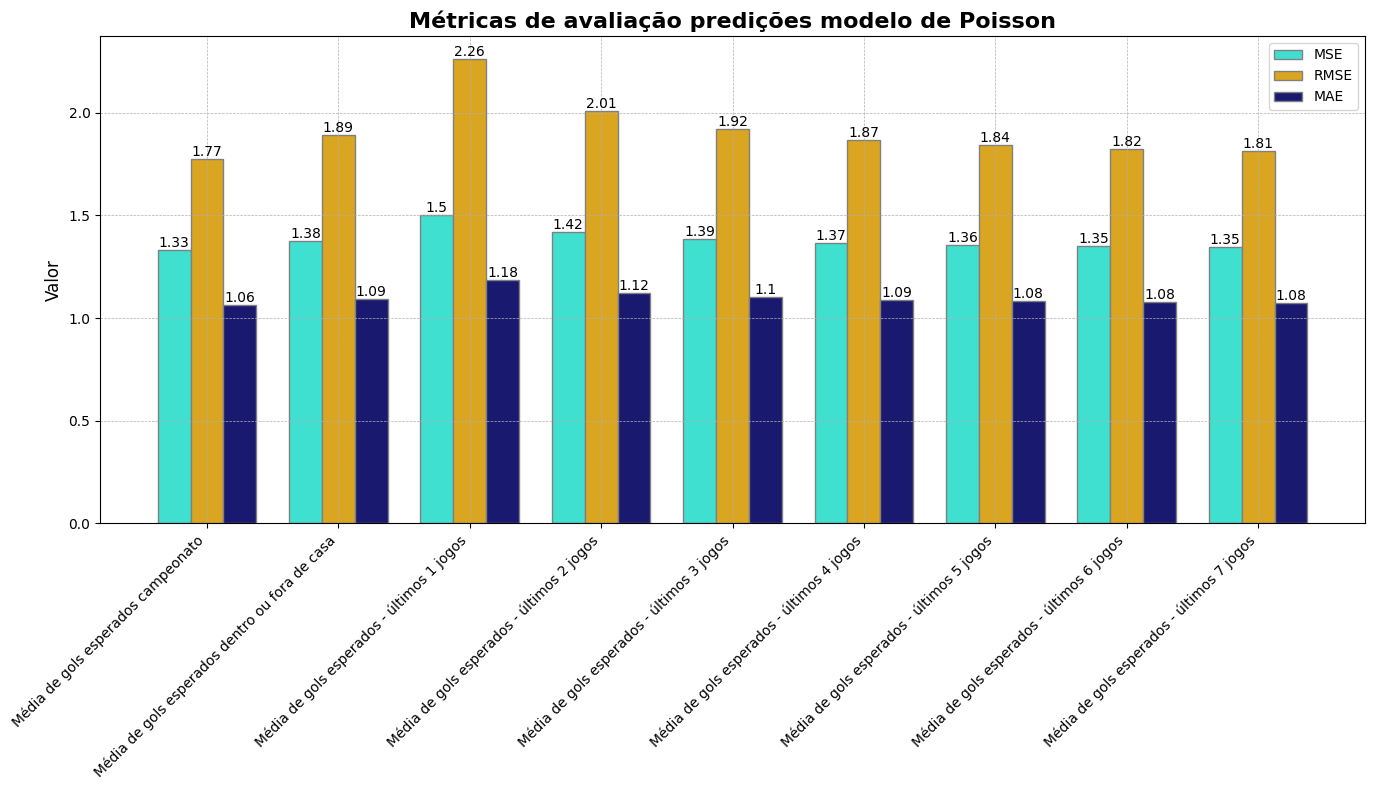

In [ ]:
# Plotando o gráfico de colunas verticais
fig, ax = plt.subplots(figsize=(14, 8))

# Definindo a largura das barras
bar_width = 0.25

# Definindo as posições no eixo x para cada grupo de barras
r1 = np.arange(len(results_df['lista_colunas']))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Criando as barras
bars1 = ax.bar(r1, results_df['MSE'], color= 'turquoise', width=bar_width, edgecolor='grey', label='MSE')
bars2 = ax.bar(r2, results_df['RMSE'], color='goldenrod', width=bar_width, edgecolor='grey', label='RMSE')
bars3 = ax.bar(r3, results_df['MAE'], color='midnightblue', width=bar_width, edgecolor='grey', label='MAE')

# Adicionando os valores nas barras
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), va='bottom', fontsize=10, ha='center', color='black')
for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), va='bottom', fontsize=10, ha='center', color='black')
for bar in bars3:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval, round(yval, 2), va='bottom', fontsize=10, ha='center', color='black')

# Adicionando os labels
# ax.set_xlabel('Média utilizada', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Métricas de avaliação predições modelo de Poisson', fontweight='bold', fontsize=16)
ax.set_xticks([r + bar_width for r in range(len(results_df['lista_colunas']))])
ax.set_xticklabels(results_df['lista_colunas'], rotation=45, ha='right')

# Adicionando a legenda
ax.legend()

# Melhorando a estética do gráfico
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Exibindo o gráfico
plt.show()

In [ ]:
 matches_rolling[['pred_poisson_gx_mean_simple','gol_pred_mean_simple']]

,pred_poisson_gx_mean_simple,gol_pred_mean_simple
0,0.000000,0
1,0.000000,0
2,0.000000,0
3,0.000000,0
4,0.000000,0
...,...,...
7413,1.418712,0
7414,1.351437,0
7415,1.923307,0
7416,2.060126,0


In [ ]:
matches_rolling = matches_rolling[matches_rolling['qnt_jogos'] > 7]
matches_rolling = matches_rolling.reset_index(drop = True)

In [ ]:
matches_rolling['qnt_jogos']

0        8.0
1        8.0
2        8.0
3        8.0
4        8.0
        ... 
5813    36.0
5814    34.0
5815    36.0
5816    35.0
5817    36.0
Name: qnt_jogos, Length: 5818, dtype: float64

In [ ]:
matches_rolling[['prob_win_1','prob_draw_1','prob_lose_1','prob_win_2','prob_draw_2','prob_lose_2','prob_win_3','prob_draw_3','prob_lose_3','prob_win_3','prob_draw_3','prob_lose_3']][-50:]

,prob_win_1,prob_draw_1,prob_lose_1,prob_win_2,prob_draw_2,prob_lose_2,prob_win_3,prob_draw_3,prob_lose_3,prob_win_3,prob_draw_3,prob_lose_3
5768,0.546104,0.210372,0.242014,0.093853,0.131122,0.763111,0.131292,0.168248,0.696203,0.131292,0.168248,0.696203
5769,0.402302,0.238198,0.359069,0.378330,0.243000,0.378330,0.388131,0.222802,0.388131,0.388131,0.222802,0.388131
5770,0.470194,0.226184,0.302838,0.081892,0.187120,0.729891,0.109115,0.176643,0.711974,0.109115,0.176643,0.711974
5771,0.266026,0.252315,0.481418,0.378330,0.243000,0.378330,0.154946,0.189249,0.653528,0.154946,0.189249,0.653528
5772,0.555296,0.221125,0.222697,0.667235,0.154985,0.165708,0.642200,0.178789,0.174715,0.642200,0.178789,0.174715
5773,0.330587,0.236669,0.432276,0.093853,0.131122,0.763111,0.079190,0.115048,0.787491,0.079190,0.115048,0.787491
5774,0.524863,0.206801,0.266418,0.885326,0.047239,0.016301,0.539512,0.188978,0.266798,0.539512,0.188978,0.266798
5775,0.412100,0.256690,0.331027,0.220213,0.185557,0.589815,0.273611,0.234896,0.490976,0.273611,0.234896,0.490976
5776,0.479539,0.231355,0.288496,0.327801,0.170902,0.485197,0.352612,0.199005,0.445022,0.352612,0.199005,0.445022
5777,0.545687,0.234185,0.219621,0.054898,0.134392,0.806463,0.186887,0.261798,0.551145,0.186887,0.261798,0.551145


In [ ]:
target = ['guo']
numerical_cols = matches_rolling.select_dtypes(include=['number']).columns
corr_matrix = matches_rolling[numerical_cols].copy().corr()
correlacoes_ftr =  matches_rolling[numerical_cols].corr()['guo'].sort_values(ascending=False)
print(correlacoes_ftr)

guo                    1.000000
all_gol                0.831272
ftga                   0.526279
ftg                    0.524101
points                 0.206433
                         ...   
gol_pred_sof_mean_5         NaN
gol_pred_mean_6             NaN
gol_pred_sof_mean_6         NaN
gol_pred_mean_7             NaN
gol_pred_sof_mean_7         NaN
Name: guo, Length: 149, dtype: float64


In [ ]:
matches_rolling.columns.tolist()

lista_principal = matches_rolling.columns.tolist()
exclude = ['level_0','index']
numerical_prime = ['points','season','venue_code','opp_code','team_code','day_code']
columns_off = ['date','team','against','ftg','ftga', 'ftr','all_gol','b365<2.5','b365>2.5','chave']
target = ['guo']
listas_exclusao = [numerical_prime, columns_off,exclude,target]

# Combinando as listas de exclusão em um único conjunto
elementos_exclusao = set(item for sublist in listas_exclusao for item in sublist)

# Usando list comprehension para remover elementos
todas_colunas = [item for item in lista_principal if item not in elementos_exclusao]
todas_colunas

['gols_acc_venue',
 'gols_against_acc_venue',
 'ftg_max_venue',
 'ftg_min_venue',
 'games_venue',
 'qnt_jogos_venue',
 'ftg_mean_venue',
 'ftga_mean_venue',
 'ftg_std_venue',
 'ftga_std_venue',
 'points_camp',
 'gols_acc',
 'gols_against_acc',
 'ftg_max',
 'ftg_min',
 'games',
 'qnt_jogos',
 'ftg_mean',
 'ftga_mean',
 'ftg_std',
 'ftga_std',
 'media_gols_feitos_ultimas_1_partidas',
 'media_gols_sofridos_ultimas_1_partidas',
 'media_gols_feitos_ultimas_2_partidas',
 'media_gols_sofridos_ultimas_2_partidas',
 'media_gols_feitos_ultimas_3_partidas',
 'media_gols_sofridos_ultimas_3_partidas',
 'media_gols_feitos_ultimas_4_partidas',
 'media_gols_sofridos_ultimas_4_partidas',
 'media_gols_feitos_ultimas_5_partidas',
 'media_gols_sofridos_ultimas_5_partidas',
 'media_gols_feitos_ultimas_6_partidas',
 'media_gols_sofridos_ultimas_6_partidas',
 'media_gols_feitos_ultimas_7_partidas',
 'media_gols_sofridos_ultimas_7_partidas',
 'ftg_mean_against',
 'ftga_mean_against',
 'ftg_mean_venue_against'

In [ ]:
matches_rolling = matches_rolling.sort_values(['date', 'chave'], ascending = [True, True]).reset_index(drop = True)
matches_rolling[-20:]

,level_0,index,date,team,against,ftg,ftga,ftr,points,season,...,prob_win_7,prob_draw_7,prob_lose_7,pred_poisson_gx_mean_6,pred_poisson_gx_sof_mean_6,prob_win_8,prob_draw_8,prob_lose_8,pred_poisson_gx_mean_7,pred_poisson_gx_sof_mean_7
5798,3,7402,2024-05-19,Everton,Arsenal,1.0,2.0,0,1,2024,...,0.195194,0.234468,0.569864,0.916622,1.746148,0.185752,0.237371,0.576465,0.857115,1.710919
5799,11,7414,2024-05-19,Arsenal,Everton,2.0,1.0,1,3,2024,...,0.569864,0.234468,0.195194,1.746148,0.916622,0.576465,0.237371,0.185752,1.710919,0.857115
5800,5,7404,2024-05-19,Aston Villa,Crystal Palace,0.0,5.0,0,1,2024,...,0.321735,0.219842,0.457341,1.581340,1.909744,0.301497,0.220363,0.477099,1.498611,1.921370
5801,0,7410,2024-05-19,Crystal Palace,Aston Villa,5.0,0.0,1,3,2024,...,0.457341,0.219842,0.321735,1.909744,1.581340,0.477099,0.220363,0.301497,1.921370,1.498611
5802,10,7398,2024-05-19,Bournemouth,Chelsea,1.0,2.0,0,1,2024,...,0.290085,0.216183,0.492466,1.498611,1.990932,0.219907,0.196839,0.580675,1.356438,2.264981
5803,12,7411,2024-05-19,Chelsea,Bournemouth,2.0,1.0,1,3,2024,...,0.492466,0.216183,0.290085,1.990932,1.498611,0.580675,0.196839,0.219907,2.264981,1.356438
5804,7,7405,2024-05-19,Newcastle,Brentford,4.0,2.0,1,3,2024,...,0.422489,0.222060,0.354480,1.828127,1.663868,0.427082,0.238311,0.334175,1.640311,1.427572
5805,16,7413,2024-05-19,Brentford,Newcastle,2.0,4.0,0,1,2024,...,0.354480,0.222060,0.422489,1.663868,1.828127,0.334175,0.238311,0.427082,1.427572,1.640311
5806,2,7400,2024-05-19,Man United,Brighton,2.0,0.0,1,3,2024,...,0.472549,0.233792,0.293115,1.746148,1.332709,0.507506,0.226735,0.265013,1.851485,1.285228
5807,4,7412,2024-05-19,Brighton,Man United,0.0,2.0,0,1,2024,...,0.293115,0.233792,0.472549,1.332709,1.746148,0.265013,0.226735,0.507506,1.285228,1.851485


In [ ]:
matches_rolling['ftr'] = matches_rolling['ftr'].astype(int)
matches_rolling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5818 entries, 0 to 5817
Columns: 153 entries, level_0 to pred_poisson_gx_sof_mean_7
dtypes: datetime64[ns](1), float64(119), int32(1), int64(26), int8(3), object(3)
memory usage: 6.7+ MB


In [ ]:
matches_rolling[todas_colunas]

,gols_acc_venue,gols_against_acc_venue,ftg_max_venue,ftg_min_venue,games_venue,qnt_jogos_venue,ftg_mean_venue,ftga_mean_venue,ftg_std_venue,ftga_std_venue,...,prob_win_7,prob_draw_7,prob_lose_7,pred_poisson_gx_mean_6,pred_poisson_gx_sof_mean_6,prob_win_8,prob_draw_8,prob_lose_8,pred_poisson_gx_mean_7,pred_poisson_gx_sof_mean_7
0,6.0,5.0,3.0,0.0,1,4.0,1.500000,1.250000,1.140175,1.000000,...,0.359331,0.281278,0.359331,1.166419,1.166419,0.367129,0.265624,0.367129,1.285228,1.285228
1,7.0,9.0,3.0,0.0,1,4.0,1.750000,2.250000,1.303840,0.447214,...,0.395030,0.246707,0.357978,1.498611,1.415722,0.356998,0.253369,0.389425,1.356438,1.427572
2,8.0,6.0,4.0,0.0,1,4.0,2.000000,1.500000,1.414214,0.894427,...,0.357978,0.246707,0.395030,1.415722,1.498611,0.389425,0.253369,0.356998,1.427572,1.356438
3,6.0,6.0,2.0,1.0,1,4.0,1.500000,1.500000,0.836660,1.095445,...,0.335985,0.224091,0.439049,1.581340,1.828127,0.370813,0.227899,0.400569,1.640311,1.710919
4,5.0,4.0,2.0,0.0,1,4.0,1.250000,1.000000,1.000000,0.447214,...,0.439049,0.224091,0.335985,1.828127,1.581340,0.400569,0.227899,0.370813,1.710919,1.640311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5813,43.0,14.0,4.0,0.0,1,17.0,2.529412,0.823529,1.294786,0.646762,...,0.544617,0.205673,0.247793,2.151725,1.415722,0.537274,0.207316,0.253605,2.128902,1.427572
5814,23.0,34.0,3.0,0.0,1,16.0,1.437500,2.125000,1.003670,1.509772,...,0.082087,0.132405,0.776818,0.833311,2.760252,0.098158,0.142013,0.751922,0.928522,2.719320
5815,42.0,14.0,5.0,0.0,1,17.0,2.470588,0.823529,1.504894,0.785905,...,0.776818,0.132405,0.082087,2.760252,0.833311,0.751922,0.142013,0.098158,2.719320,0.928522
5816,28.0,32.0,4.0,0.0,1,17.0,1.647059,1.882353,1.074055,1.437136,...,0.459285,0.209262,0.329571,2.071619,1.746148,0.478434,0.206882,0.312591,2.128902,1.710919


##5.0 Seleção de Features


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif, mutual_info_classif


y = matches_rolling['ftg']
x = matches_rolling[todas_colunas]
# x = x.drop(['ftr_rolling_3', 'ftr_rolling_5'], axis=1)

f_classif = SelectKBest(score_func=f_classif, k = 10)

fit = f_classif.fit(x,y)

features = fit.transform(x)

# print(features)

cols_kbest_frt = fit.get_support(indices=True)
x.iloc[:,cols_kbest_frt]

# matches_rolling[predictors].info()
# matches_rolling[new_cols_3].info()
# matches_rolling[new_cols_5].info()
# matches_rolling[lista_prob].info()
# y.info()

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [ 4 15 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,ftg_std_venue,ftg_std,gx_mean_simple,gx_mean_venue,prob_win_0,prob_lose_0,pred_poisson_gx_mean_simple,prob_win_1,prob_lose_1,pred_poisson_gx_mean_venue
0,1.140175,0.866025,1.312500,1.250000,0.379787,0.354584,1.311940,0.339888,0.398131,1.249600
1,1.303840,1.130388,1.375000,1.625000,0.347683,0.403605,1.374229,0.296972,0.492719,1.622632
2,1.414214,1.322876,1.500000,2.125000,0.403605,0.347683,1.498611,0.492719,0.296972,2.111750
3,0.836660,0.726483,1.562500,1.250000,0.369070,0.395751,1.560675,0.339888,0.398131,1.249600
4,1.000000,1.130388,1.625000,1.375000,0.395751,0.369070,1.622632,0.398131,0.339888,1.374229
...,...,...,...,...,...,...,...,...,...,...
5813,1.294786,1.204970,1.930556,2.181373,0.547519,0.230685,1.923307,0.622603,0.177528,2.165794
5814,1.003670,1.108051,1.171429,1.130515,0.209785,0.579426,1.171174,0.174618,0.632691,1.130316
5815,1.504894,1.378981,2.071429,2.297794,0.579426,0.209785,2.060126,0.632691,0.174618,2.276387
5816,1.074055,1.004494,2.208333,2.176471,0.576932,0.219605,2.191533,0.528929,0.263482,2.161107


In [ ]:
cols_kbest = x.columns[cols_kbest_frt].tolist()
cols_kbest

['ftg_std_venue',
 'ftg_std',
 'gx_mean_simple',
 'gx_mean_venue',
 'prob_win_0',
 'prob_lose_0',
 'pred_poisson_gx_mean_simple',
 'prob_win_1',
 'prob_lose_1',
 'pred_poisson_gx_mean_venue']

In [ ]:
# from sklearn.feature_selection import SelectKBest
# from sklearn.feature_selection import f_classif, mutual_info_classif


# y = matches_rolling['ftg']
# x = matches_rolling[todas_colunas]
# # x = x.drop(['ftr_rolling_3', 'ftr_rolling_5'], axis=1)

# f_classif = SelectKBest(score_func=f_classif, k = 10)

# fit = f_classif.fit(x,y)

# features = fit.transform(x)

# # print(features)

# cols_kbest_frt = fit.get_support(indices=True)
# x.iloc[:,cols_kbest_frt]

In [ ]:
# cols_kbest_frt

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import xgboost as xgb
xgb.XGBClassifier(random_state=82)

# Crie o modelo LinearSVC
# model = LinearSVC()
model = LinearRegression()

# Use o modelo LinearSVC no RFE
rfe = RFE(model, n_features_to_select=10)
fit = rfe.fit(x, y)

# Obtenha o número de features selecionadas
selected_features = fit.n_features_
print(selected_features)

teste = fit.get_support(indices=True)
df_teste = x.iloc[:,teste]
df_teste.info()

10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5818 entries, 0 to 5817
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gx_mean_simple                   5818 non-null   float64
 1   gx_sof_mean_simple               5818 non-null   float64
 2   prob_win_0                       5818 non-null   float64
 3   prob_draw_0                      5818 non-null   float64
 4   prob_lose_0                      5818 non-null   float64
 5   pred_poisson_gx_mean_simple      5818 non-null   float64
 6   pred_poisson_gx_sof_mean_simple  5818 non-null   float64
 7   prob_win_1                       5818 non-null   float64
 8   prob_draw_1                      5818 non-null   float64
 9   prob_lose_1                      5818 non-null   float64
dtypes: float64(10)
memory usage: 454.7 KB


In [ ]:
cols_RFE_linear_regression = x.columns[teste].tolist()
cols_RFE_linear_regression

['gx_mean_simple',
 'gx_sof_mean_simple',
 'prob_win_0',
 'prob_draw_0',
 'prob_lose_0',
 'pred_poisson_gx_mean_simple',
 'pred_poisson_gx_sof_mean_simple',
 'prob_win_1',
 'prob_draw_1',
 'prob_lose_1']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score


# Crie o modelo LinearSVC
# model = LinearSVC()
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Use o modelo LinearSVC no RFE
rfe = RFE(model, n_features_to_select=10)
fit = rfe.fit(x, y)

# Obtenha o número de features selecionadas
selected_features = fit.n_features_
print(selected_features)

rand = fit.get_support(indices=True)
df_teste = x.iloc[:,rand]
df_teste.info()

10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5818 entries, 0 to 5817
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ftg_max_venue                5818 non-null   float64
 1   ftg_mean_venue               5818 non-null   float64
 2   ftg_std_venue                5818 non-null   float64
 3   points_camp                  5818 non-null   float64
 4   ftg_std                      5818 non-null   float64
 5   gx_mean_venue                5818 non-null   float64
 6   prob_win_0                   5818 non-null   float64
 7   pred_poisson_gx_mean_simple  5818 non-null   float64
 8   prob_win_1                   5818 non-null   float64
 9   prob_win_4                   5818 non-null   float64
dtypes: float64(10)
memory usage: 454.7 KB


In [ ]:
cols_RFE_rand_forest= x.columns[rand].tolist()
cols_RFE_rand_forest

['ftg_max_venue',
 'ftg_mean_venue',
 'ftg_std_venue',
 'points_camp',
 'ftg_std',
 'gx_mean_venue',
 'prob_win_0',
 'pred_poisson_gx_mean_simple',
 'prob_win_1',
 'prob_win_4']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb
xgb.XGBClassifier(random_state=82)

model = RandomForestRegressor(random_state = 42)
model.fit(x,y)
fit = rfe.fit(x, y)

rand = fit.get_support(indices=True)
# print(model.feature_importances_)

features_imp = pd.DataFrame(model.feature_importances_,
                            index = x.columns,
                            columns = ['importance']).sort_values('importance', ascending = False)

# features_imp.plot(kind = 'bar', figsize=(20,15))

rand

array([  2,   6,   8,  10,  19,  55,  89,  92,  94, 109])

In [ ]:
cols_RFE_rand_forest= x.columns[rand].tolist()
cols_RFE_rand_forest

['ftg_max_venue',
 'ftg_mean_venue',
 'ftg_std_venue',
 'points_camp',
 'ftg_std',
 'gx_mean_venue',
 'prob_win_0',
 'pred_poisson_gx_mean_simple',
 'prob_win_1',
 'prob_win_4']

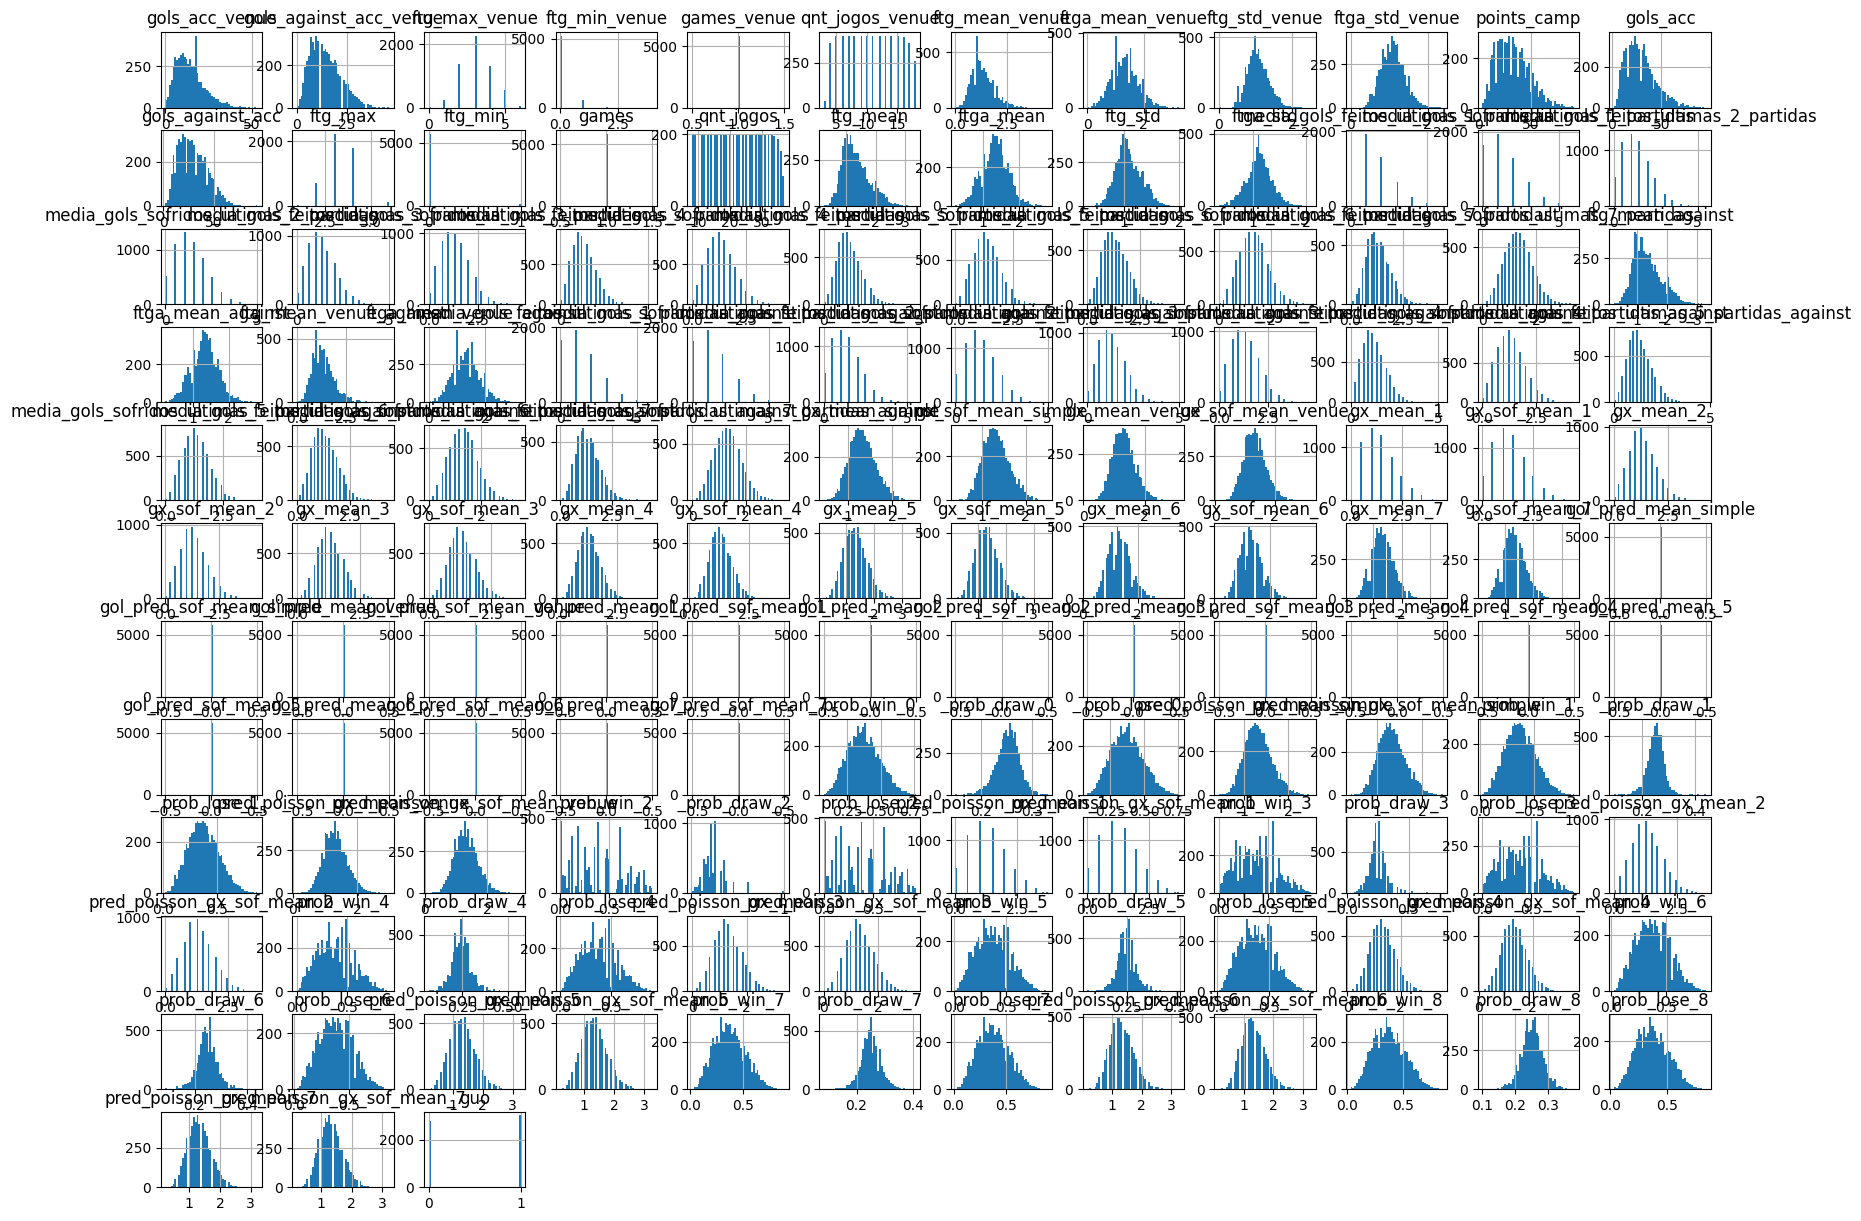

In [ ]:
df_mach = matches_rolling[todas_colunas + target]
g = df_mach.hist(bins=50, figsize=(20,15)) # Histograms

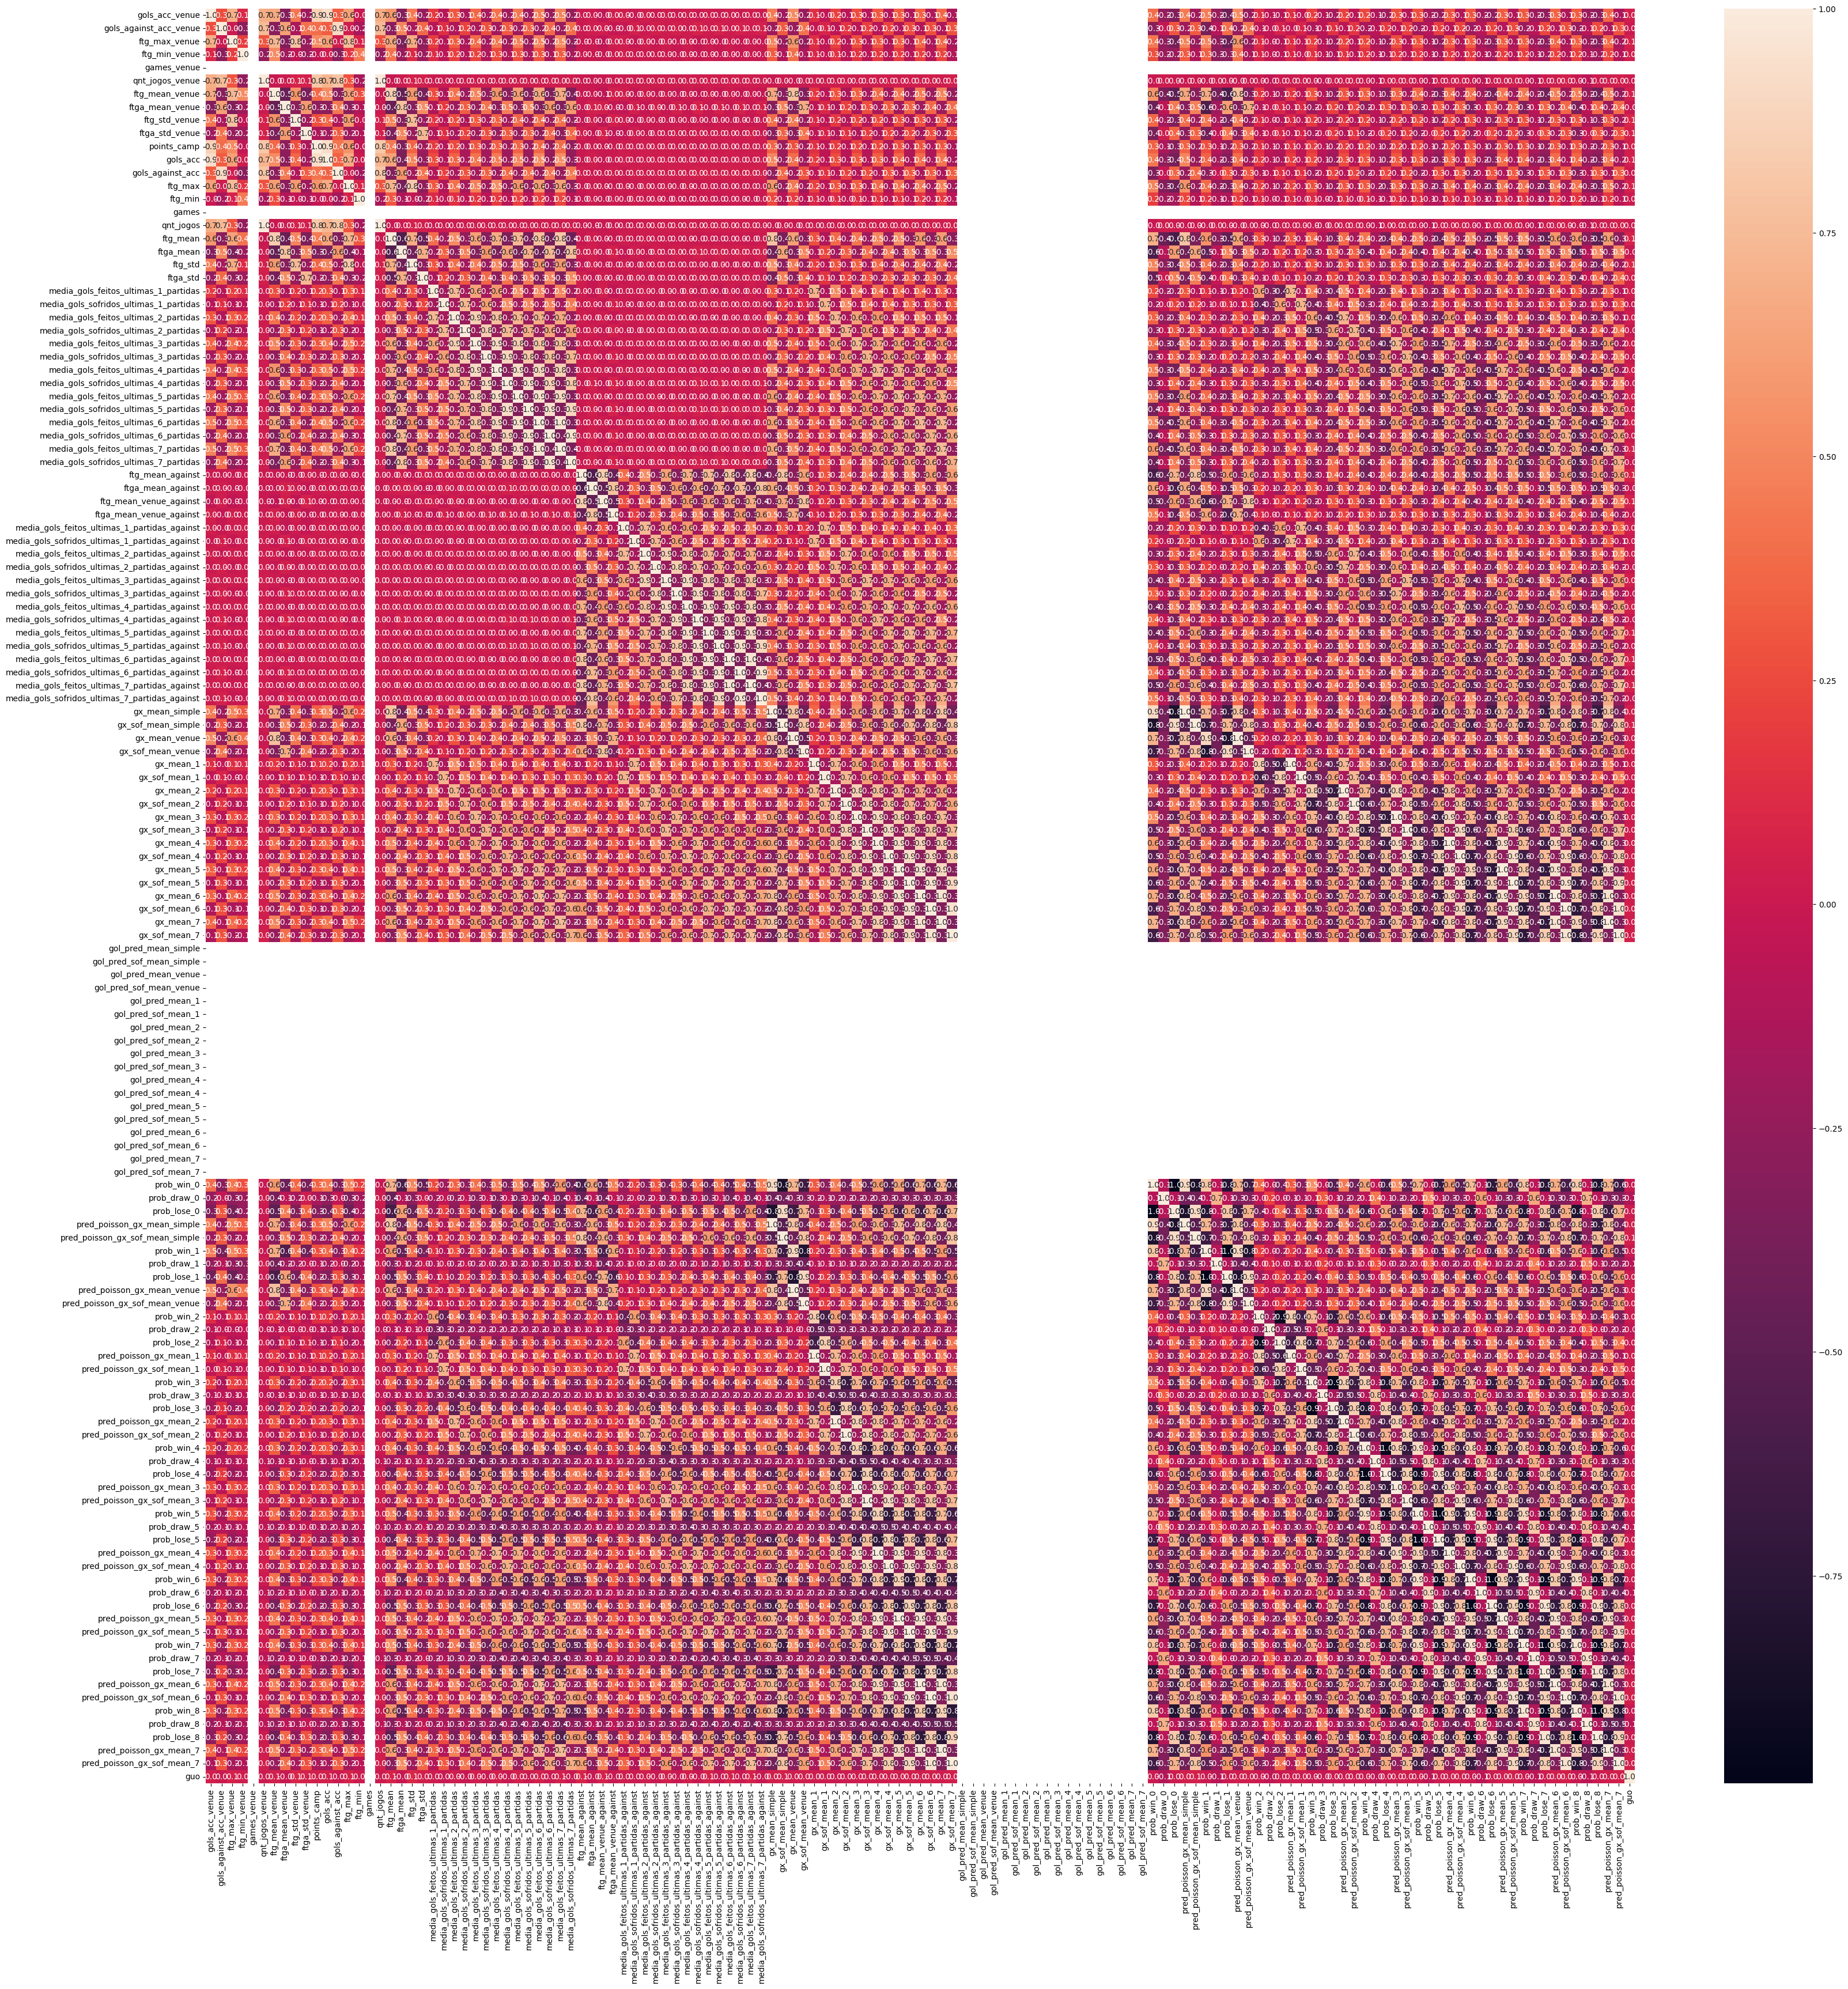

In [ ]:
df_corr = df_mach.corr()

plt.figure(figsize=(40,40))
sns.heatmap(df_corr, annot=True, fmt='.1f')

plt.show()

In [ ]:
pred_cols = [f'pred_poisson_{col}' for col in gx_cols_sof]

mse_poisson_results = {}
rmse_poisson_results = {}
mae_poisson_results =  {}
r2_poisson_results =  {}

for i,col in enumerate(list_sufixo):
    mse_key = f'mean_{col}'
    rmse_key = f'mean_{col}'
    mae_key = f'mean_{col}'
    r2_key = f'mean_{col}'
    mse_value = mean_squared_error(matches_rolling['ftg'], matches_rolling[pred_cols[i]], squared=False)
    rmse_value = mean_squared_error(matches_rolling['ftg'], matches_rolling[pred_cols[i]], squared=True)
    mae_value = mean_absolute_error(matches_rolling['ftg'], matches_rolling[pred_cols[i]])
    r2_value = r2_score(matches_rolling['ftg'], matches_rolling[pred_cols[i]])
    mse_poisson_results[mse_key] = mse_value
    rmse_poisson_results[rmse_key] = rmse_value
    mae_poisson_results[mae_key] = mae_value
    r2_poisson_results[r2_key] = r2_value

mse_poisson_results
mse_df = pd.DataFrame(list(mse_poisson_results.items()), columns=['Indicator', 'MSE'])
rmse_df = pd.DataFrame(list(rmse_poisson_results.items()), columns=['Indicator', 'RMSE'])
mae_df = pd.DataFrame(list(mae_poisson_results.items()), columns=['Indicator', 'MAE'])
r2_df = pd.DataFrame(list(r2_poisson_results.items()), columns=['Indicator', 'R2'])

results_df_possion = mse_df.merge(rmse_df, on='Indicator').merge(mae_df, on='Indicator').merge(r2_df, on='Indicator')
results_df_possion['base'] = 'poisson'
results_df_possion

,Indicator,MSE,RMSE,MAE,R2,base
0,mean_simple,1.302769,1.697206,1.046603,-0.184361,poisson
1,mean_venue,1.336507,1.786251,1.072390,-0.246500,poisson
2,mean_1,1.496686,2.240069,1.182811,-0.563188,poisson
3,mean_2,1.406028,1.976915,1.117363,-0.379551,poisson
4,mean_3,1.369622,1.875864,1.093593,-0.309035,poisson
5,mean_4,1.346775,1.813802,1.078817,-0.265726,poisson
6,mean_5,1.335501,1.783562,1.069781,-0.244623,poisson
7,mean_6,1.328041,1.763692,1.065405,-0.230757,poisson
8,mean_7,1.322504,1.749016,1.061265,-0.220516,poisson


In [ ]:
coef = ['lr','svr','tree','xg']
modelos = ['Linear_regression', 'SVC', 'Rand_forest', 'XG_boost']

mae = [f'mae_{col}' for col in coef]
mse = [f'mse_{col}' for col in coef]
rmse = [f'rmse_{col}' for col in coef]
r2 = [f'r2_{col}' for col in coef]


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Split data into features and label

lista_group_colunas = [todas_colunas, cols_kbest, cols_RFE_linear_regression,cols_RFE_rand_forest]
lista_group_colunas_name = ['todas_colunas', 'cols_kbest', 'cols_RFE_linear_regression','cols_RFE_rand_forest']
df_indicadores = pd.DataFrame()

for i in range(len(lista_group_colunas)):

    mse_results = {}
    rmse_results = {}
    mae_results =  {}
    r2_results =  {}

    target = ["ftg"]
    date = ["date"]
    categorical_columns = ['team', 'against']
    predictors = ['venue_code', 'day_code']

    df = matches_rolling[date + lista_group_colunas[i] + categorical_columns + target].copy()
    X = df[date + lista_group_colunas[i] + categorical_columns + target]
    y = df['ftg']

    # Pipeline para aplicar as transformações e treinar o modelo

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), lista_group_colunas[i]),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
        ])

    pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', LinearRegression())])

    pipeline_svr = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', SVR())])

    pipeline_tree = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('regressor', RandomForestRegressor(random_state = 42))])

    pipeline_xg = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', xgb.XGBRegressor(random_state=82))])

    # Realize a validação cruzada para cada modelo
    lr_preds = cross_val_predict(pipeline_lr, X, y, cv=5)  # Você pode ajustar o número de folds (cv) conforme necessário
    svr_preds = cross_val_predict(pipeline_svr, X, y, cv=5)
    tree_preds = cross_val_predict(pipeline_tree, X, y, cv=5)
    xg_preds = cross_val_predict(pipeline_xg, X, y, cv=5)

    mse_lr = mean_squared_error(y, lr_preds)
    mse_svr = mean_squared_error(y, svr_preds)
    mse_tree = mean_squared_error(y, tree_preds)
    mse_xg = mean_squared_error(y, xg_preds)

    rmse_lr = np.sqrt(mse_lr)
    rmse_svr = np.sqrt(mse_svr)
    rmse_tree = np.sqrt(mse_tree)
    rmse_xg = np.sqrt(mse_xg)

    mae_lr = mean_absolute_error(y, lr_preds)
    mae_svr = mean_absolute_error(y, svr_preds)
    mae_tree = mean_absolute_error(y, tree_preds)
    mae_xg = mean_absolute_error(y, xg_preds)

    r2_lr = r2_score(y, lr_preds)
    r2_svr = r2_score(y, svr_preds)
    r2_tree = r2_score(y, tree_preds)
    r2_xg = r2_score(y, xg_preds)

    mse_var = [mse_lr,mse_svr,mse_tree,mse_xg]
    rmse_var = [rmse_lr,rmse_svr,rmse_tree,rmse_xg]
    mae_var = [mae_lr,mae_svr,mae_tree,mae_xg]
    r2_var = [r2_lr,r2_svr,r2_tree,r2_xg]

    for j,col in enumerate(modelos):
        mse_key = col
        rmse_key =col
        mae_key = col
        r2_key = col
        mse_results[mse_key] = mse_var[j]
        rmse_results[rmse_key] = rmse_var[j]
        mae_results[mae_key] = mae_var[j]
        r2_results[r2_key] = r2_var[j]

    mse_poisson_results
    mse_df = pd.DataFrame(list(mse_results.items()), columns=['Indicator', 'MSE'])
    rmse_df = pd.DataFrame(list(rmse_results.items()), columns=['Indicator', 'RMSE'])
    mae_df = pd.DataFrame(list(mae_results.items()), columns=['Indicator', 'MAE'])
    r2_df = pd.DataFrame(list(r2_results.items()), columns=['Indicator', 'R2'])

    results_df = mse_df.merge(rmse_df, on='Indicator').merge(mae_df, on='Indicator').merge(r2_df, on='Indicator')
    results_df['base'] = lista_group_colunas_name[i]
    df_indicadores = pd.concat([df_indicadores, results_df])

    print('\n\n',"----------------------------------------------------------------------------------------------------------------------------", '\n\n')
    print('SEPARAÇÃO USANDO CROSS VALIDATION','\n')
    print("O conjunto de colunas foi:", lista_group_colunas_name[i], '\n')
    print("Linear Regression: \n")
    print(f'Mean Squared Error: {mse_lr}')
    print(f'Root Mean Squared Error: {rmse_lr}')
    print(f'Mean Absolute Error: {mae_lr}')
    print(f'R-squared: {r2_lr}')
    print("Support Vector Regressor (SVR): \n")
    print(f'Mean Squared Error: {mse_svr}')
    print(f'Root Mean Squared Error: {rmse_svr}')
    print(f'Mean Absolute Error: {mae_svr}')
    print(f'R-squared: {r2_svr}')
    print("Decision Tree Regressor: \n")
    print(f'Mean Squared Error: {mse_tree}')
    print(f'Root Mean Squared Error: {rmse_tree}')
    print(f'Mean Absolute Error: {mae_tree}')
    print(f'R-squared: {r2_tree}')
    print("XGBoost Regressor: \n")
    print(f'Mean Squared Error: {mse_xg}')
    print(f'Root Mean Squared Error: {rmse_xg}')
    print(f'Mean Absolute Error: {mae_xg}')
    print(f'R-squared: {r2_xg}')




 ---------------------------------------------------------------------------------------------------------------------------- 


SEPARAÇÃO USANDO CROSS VALIDATION 

O conjunto de colunas foi: todas_colunas 

Linear Regression: 

Mean Squared Error: 5.948130927629005e+18
Root Mean Squared Error: 2438879030.9543858
Mean Absolute Error: 223064627.8998326
R-squared: -4.1507852181591936e+18
Support Vector Regressor (SVR): 

Mean Squared Error: 1.2397471958657846
Root Mean Squared Error: 1.1134393543726504
Mean Absolute Error: 0.8956583246317914
R-squared: 0.13486700318729605
Decision Tree Regressor: 

Mean Squared Error: 1.1465014953592298
Root Mean Squared Error: 1.0707481007964619
Mean Absolute Error: 0.8596167067720867
R-squared: 0.1999366662509816
XGBoost Regressor: 

Mean Squared Error: 1.2694331418359068
Root Mean Squared Error: 1.1266912362470505
Mean Absolute Error: 0.8961577913486173
R-squared: 0.11415125445562302


 ---------------------------------------------------------------

In [ ]:
mse_results

{'Linear_regression': 1.2035496358784488,
 'SVC': 1.1262231338489308,
 'Rand_forest': 1.1230099518734962,
 'XG_boost': 1.2087028764670709}

In [ ]:
results_df

,Indicator,MSE,RMSE,MAE,R2,base
0,Linear_regression,1.203550,1.097064,0.887247,0.160127,cols_RFE_rand_forest
1,SVC,1.126223,1.061237,0.849868,0.214088,cols_RFE_rand_forest
2,Rand_forest,1.123010,1.059722,0.849245,0.216330,cols_RFE_rand_forest
3,XG_boost,1.208703,1.099410,0.874625,0.156531,cols_RFE_rand_forest


In [ ]:
df_indicadores

,Indicator,MSE,RMSE,MAE,R2,base
0,Linear_regression,5.948131e+18,2.438879e+09,2.230646e+08,-4.150785e+18,todas_colunas
1,SVC,1.239747e+00,1.113439e+00,8.956583e-01,1.348670e-01,todas_colunas
2,Rand_forest,1.146501e+00,1.070748e+00,8.596167e-01,1.999367e-01,todas_colunas
3,XG_boost,1.269433e+00,1.126691e+00,8.961578e-01,1.141513e-01,todas_colunas
0,Linear_regression,1.237437e+00,1.112402e+00,8.945877e-01,1.364790e-01,cols_kbest
1,SVC,1.248204e+00,1.117231e+00,8.848027e-01,1.289652e-01,cols_kbest
2,Rand_forest,1.257502e+00,1.121384e+00,8.972207e-01,1.224769e-01,cols_kbest
3,XG_boost,1.397779e+00,1.182277e+00,9.376322e-01,2.458766e-02,cols_kbest
0,Linear_regression,1.265371e+00,1.124887e+00,8.953913e-01,1.169861e-01,cols_RFE_linear_regression
1,SVC,1.301508e+00,1.140836e+00,8.906249e-01,9.176857e-02,cols_RFE_linear_regression


In [ ]:
df_final = pd.concat([results_df_possion,df_indicadores])
df_final = df_final.reset_index(drop=True)
df_final

,Indicator,MSE,RMSE,MAE,R2,base
0,mean_simple,1.302769e+00,1.697206e+00,1.046603e+00,-1.843614e-01,poisson
1,mean_venue,1.336507e+00,1.786251e+00,1.072390e+00,-2.465002e-01,poisson
2,mean_1,1.496686e+00,2.240069e+00,1.182811e+00,-5.631875e-01,poisson
3,mean_2,1.406028e+00,1.976915e+00,1.117363e+00,-3.795506e-01,poisson
4,mean_3,1.369622e+00,1.875864e+00,1.093593e+00,-3.090347e-01,poisson
5,mean_4,1.346775e+00,1.813802e+00,1.078817e+00,-2.657260e-01,poisson
6,mean_5,1.335501e+00,1.783562e+00,1.069781e+00,-2.446234e-01,poisson
7,mean_6,1.328041e+00,1.763692e+00,1.065405e+00,-2.307573e-01,poisson
8,mean_7,1.322504e+00,1.749016e+00,1.061265e+00,-2.205161e-01,poisson
9,Linear_regression,5.948131e+18,2.438879e+09,2.230646e+08,-4.150785e+18,todas_colunas


In [ ]:
df_final['MSE'] = df_final['MSE'].round(3)
df_final[10:]

,Indicator,MSE,RMSE,MAE,R2,base
10,SVC,1.240,1.113439,0.895658,0.134867,todas_colunas
11,Rand_forest,1.147,1.070748,0.859617,0.199937,todas_colunas
12,XG_boost,1.269,1.126691,0.896158,0.114151,todas_colunas
13,Linear_regression,1.237,1.112402,0.894588,0.136479,cols_kbest
14,SVC,1.248,1.117231,0.884803,0.128965,cols_kbest
15,Rand_forest,1.258,1.121384,0.897221,0.122477,cols_kbest
16,XG_boost,1.398,1.182277,0.937632,0.024588,cols_kbest
17,Linear_regression,1.265,1.124887,0.895391,0.116986,cols_RFE_linear_regression
18,SVC,1.302,1.140836,0.890625,0.091769,cols_RFE_linear_regression
19,Rand_forest,1.315,1.146570,0.915029,0.082617,cols_RFE_linear_regression


This project demonstrates an end-to-end approach to sports analytics using real match data.
It combines web scraping, feature engineering, statistical and machine learning modeling, and visual storytelling via dashboards.


## 10. Conclusion

This project demonstrates the application of statistical and machine learning techniques to predict football match outcomes.
The final dataset is used in a Power BI report to analyze probabilities, team performance, and trends over time.
